#  Detecção de fraude em transações de cartão

## Integrantes: Gustavo Saul Rech, João Valandro, Manuella Schmidt, Matheus Viegas & Rafaella Silva dos Santos
## Arquitetura principal: MLP sobre dados tabulares

O cliente. Uma fintech em crescimento processa milhares de transações por hora. Hoje a  checagem é por regras fixas, que os fraudadores já aprenderam a contornar. Bloquear uma  compra legítima gera reclamação e cancelamento de conta; liberar uma fraude gera prejuízo direto. Os dados. 284.807 transações de cartões europeus, das quais 492 são fraudes, ou seja, 0,172% do total. As variáveis foram anonimizadas por PCA.

---
## Parte 0: Bibliotecas e semente

Pandas e NumPy para os dados, Matplotlib para os gráficos, scikit-learn para dividir, escalar e
medir, e TensorFlow/Keras para a MLP. As métricas já entram todas aqui porque, com 0,17% de
fraudes, acurácia sozinha não diz nada: vamos precisar de precisão, recall, F1 e PR-AUC.

In [ ]:
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

Fixamos a mesma semente no Python, no NumPy e no TensorFlow, para que a divisão dos dados e
os pesos iniciais da rede sejam iguais a cada execução.

In [ ]:
SEMENTE = 42

random.seed(SEMENTE)
np.random.seed(SEMENTE)
tf.random.set_seed(SEMENTE)

---
## Parte 1: Importação dos dados e visualização inicial

O conjunto é o **Credit Card Fraud Detection** (`mlg-ulb/creditcardfraud`) do Kaggle. O
`kagglehub` baixa o arquivo na primeira execução; no Colab, ele reaproveita o cache.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


Lemos o `creditcard.csv` e olhamos as primeiras linhas: `Time`, as componentes `V1` a `V28`,
`Amount` e o rótulo `Class` (0 = legítima, 1 = fraude).

In [ ]:
import os

arquivo = os.path.join(path, "creditcard.csv")

df = pd.read_csv(arquivo)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Tamanho do conjunto, nome das colunas e tipo de cada uma:

In [ ]:
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")

Linhas: 284807
Colunas: 31


In [ ]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
print("Total de valores ausentes:", df.isnull().sum().sum())

Total de valores ausentes: 0


São **284.807 linhas e 31 colunas**, todas numéricas (30 `float64` e o `Class` em `int64`), e
**nenhum valor ausente**. Não há nada para preencher nem para converter.

> **Por que `V1` a `V28`?** As variáveis originais foram anonimizadas por PCA. Não sabemos o
> que cada uma significa, só que são combinações das variáveis reais da transação. As únicas
> que mantêm o sentido original são `Time` e `Amount`.

In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


Conferimos se há valores ausentes:

In [ ]:
duplicadas = df.duplicated().sum()

print(f"Linhas duplicadas: {duplicadas}")

Linhas duplicadas: 1081


A contagem das duas classes, em números absolutos e em percentual:

In [ ]:
contagem_classes = df["Class"].value_counts()

print(f"Transações legítimas: {contagem_classes[0]}")
print(f"Fraudes: {contagem_classes[1]}")

Transações legítimas: 284315
Fraudes: 492


In [ ]:
proporcao_classes = df["Class"].value_counts(normalize=True) * 100

print(f"Transações legítimas: {proporcao_classes[0]:.4f}%")
print(f"Fraudes: {proporcao_classes[1]:.4f}%")

Transações legítimas: 99.8273%
Fraudes: 0.1727%


São **492 fraudes contra 284.315 legítimas**: 0,1727% do total. Guarde esse número: um modelo
que responda "legítima" para tudo já acerta 99,83%, sem detectar fraude nenhuma. Por isso a
acurácia não serve como métrica principal neste problema.

---
## Parte 2: Exploração dos dados

Agora comparamos as duas classes: o valor (`Amount`), o horário (`Time`) e as componentes PCA,
procurando o que diferencia uma fraude de uma transação legítima.

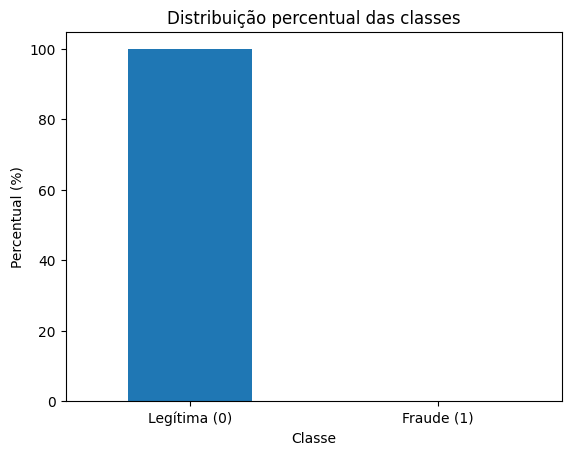

In [ ]:
proporcao_classes.plot(kind="bar")

plt.title("Distribuição percentual das classes")
plt.xlabel("Classe")
plt.ylabel("Percentual (%)")
plt.xticks(
    ticks=[0, 1],
    labels=["Legítima (0)", "Fraude (1)"],
    rotation=0
)

plt.show()

Separamos as duas classes em `df_legitimas` e `df_fraudes` (usadas nos gráficos seguintes) e
comparamos o `Amount` de cada uma.

In [ ]:
df_legitimas = df[df["Class"] == 0]
df_fraudes = df[df["Class"] == 1]

display(
    df.groupby("Class")["Amount"]
    .describe()
)

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


A média das fraudes é **maior** (122,21 contra 88,29), mas a mediana é **menor** (9,25 contra
22,00). Ou seja, a maioria das fraudes é de valor baixo, e algumas poucas de valor alto puxam a
média para cima. O maior valor de fraude é 2.125,87, bem abaixo do máximo das legítimas
(25.691,16).

Os histogramas do `Amount` para cada classe, separados:

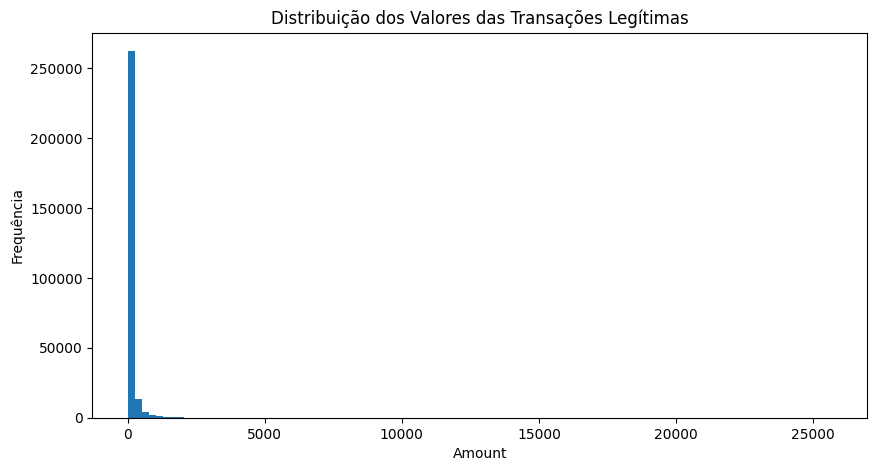

In [ ]:
# Distribuição dos valores das transações legítimas

plt.figure(figsize=(10, 5))

plt.hist(df[df["Class"] == 0]["Amount"], bins=100)

plt.title("Distribuição dos Valores das Transações Legítimas")
plt.xlabel("Amount")
plt.ylabel("Frequência")

plt.show()

Distribuição dos valores das transações fraudulentas

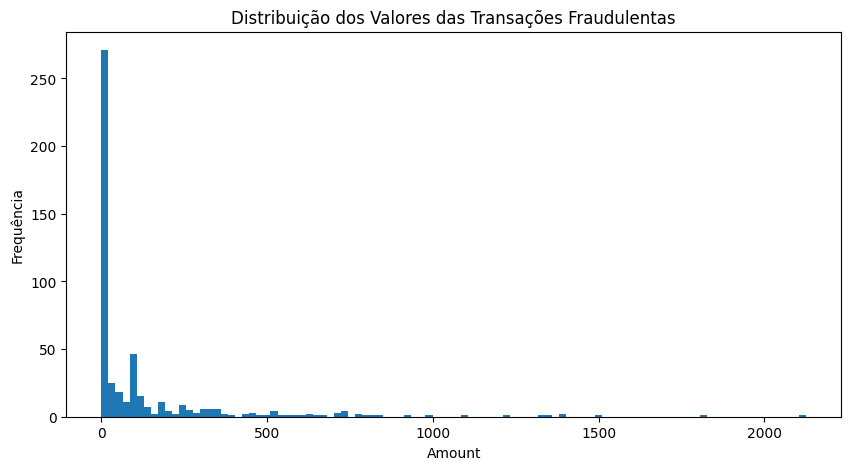

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(df[df["Class"] == 1]["Amount"], bins=100)

plt.title("Distribuição dos Valores das Transações Fraudulentas")
plt.xlabel("Amount")
plt.ylabel("Frequência")

plt.show()

O mesmo `Amount` em um boxplot por classe:

<Figure size 800x500 with 0 Axes>

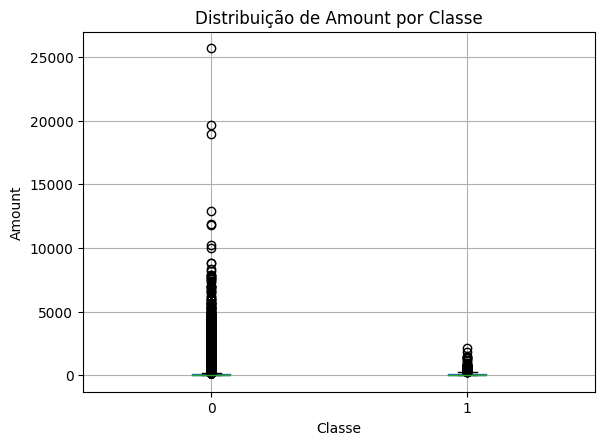

In [ ]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="Amount",
    by="Class"
)

plt.title("Distribuição de Amount por Classe")
plt.suptitle("")
plt.xlabel("Classe")
plt.ylabel("Amount")

plt.show()

Nos histogramas e no boxplot, quase tudo se concentra perto de zero e os valores extremos
esmagam o resto do gráfico. Na seção 2.5 refazemos o boxplot sem os outliers.

`Time` são os segundos desde a primeira transação do conjunto. Os histogramas de cada classe:

Distribuição das transações legítimas ao longo do tempo

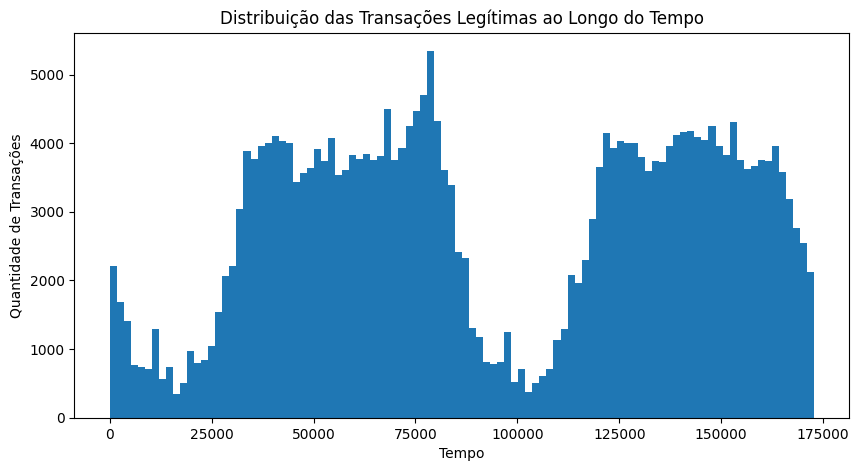

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(df[df["Class"] == 0]["Time"], bins=100)

plt.title("Distribuição das Transações Legítimas ao Longo do Tempo")
plt.xlabel("Tempo")
plt.ylabel("Quantidade de Transações")

plt.show()

Distribuição das transações fraudulentas ao longo do tempo



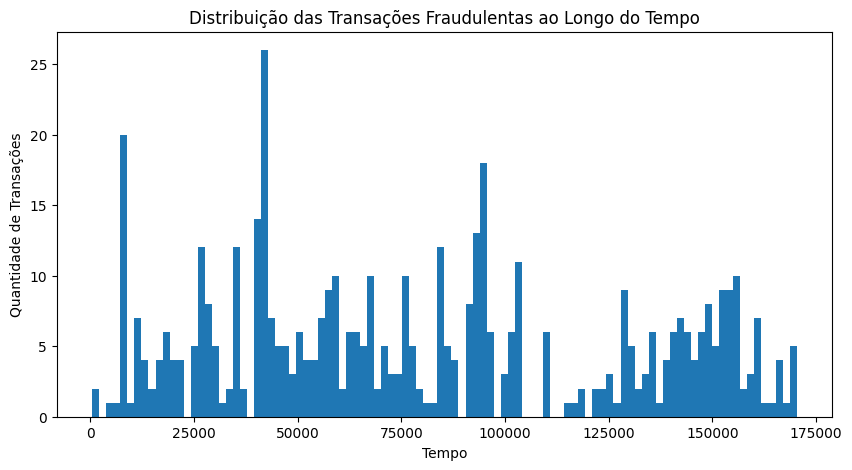

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(df[df["Class"] == 1]["Time"], bins=100)

plt.title("Distribuição das Transações Fraudulentas ao Longo do Tempo")
plt.xlabel("Tempo")
plt.ylabel("Quantidade de Transações")

plt.show()


Primeiro, a correlação de cada coluna com `Class`. Como algumas correlações são negativas,
ordenamos pelo valor absoluto para ver as mais fortes em qualquer direção.

In [ ]:
correlacoes = (
    df.corr(numeric_only=True)["Class"]
    .sort_values(ascending=False)
)

In [ ]:
correlacoes_abs = (
    df.corr(numeric_only=True)["Class"]
    .drop("Class")
    .abs()
    .sort_values(ascending=False)
)

In [ ]:
top_features = correlacoes_abs.head(10).index

top_features

Index(['V17', 'V14', 'V12', 'V10', 'V16', 'V3', 'V7', 'V11', 'V4', 'V18'], dtype='object')

As 10 colunas mais correlacionadas com a fraude são **V17, V14, V12, V10, V16, V3, V7, V11, V4
e V18**. Nenhuma delas é `Time` ou `Amount`. Agora a média de cada componente, separada por classe:

In [ ]:
colunas_v = [f"V{i}" for i in range(1, 29)]

In [ ]:
medias_v = df.groupby("Class")[colunas_v].mean().T

medias_v.columns = ["Legítima", "Fraude"]

display(medias_v.T)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28
Legítima,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,0.009824,...,-0.001178,-0.000644,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131
Fraude,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,-5.676883,...,0.680659,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667


Nas legítimas, todas as médias ficam perto de zero. Nas fraudes, várias se afastam bastante:
V3 (−7,03), V10 (−5,68), V7 (−5,57), V1 (−4,77), V4 (4,54) e V2 (3,62).

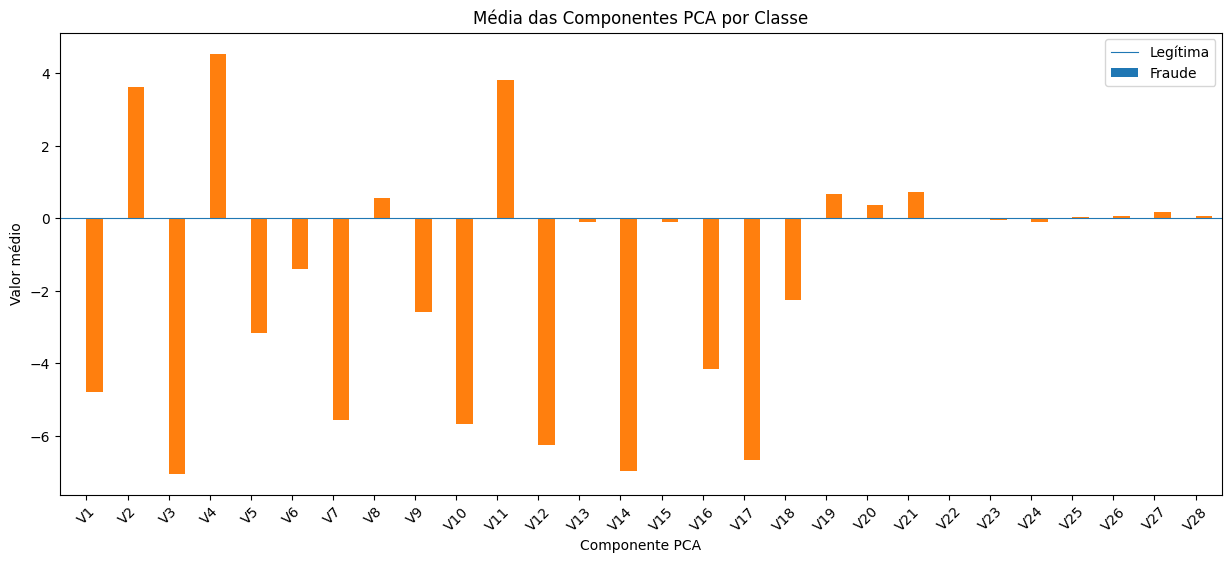

In [ ]:
medias_v.plot(
    kind="bar",
    figsize=(15, 6),
    width=0.8
)

plt.title("Média das Componentes PCA por Classe")
plt.xlabel("Componente PCA")
plt.ylabel("Valor médio")
plt.axhline(0, linewidth=0.8)
plt.xticks(rotation=45)
plt.legend(["Legítima", "Fraude"])

plt.show()

No gráfico, as barras das legítimas praticamente somem; as das fraudes mostram quais
componentes se deslocam, e em que direção. A média resume demais. Os histogramas das 28 componentes, com as duas classes sobrepostas
(`density=True`, para que as 492 fraudes fiquem na mesma escala das legítimas):

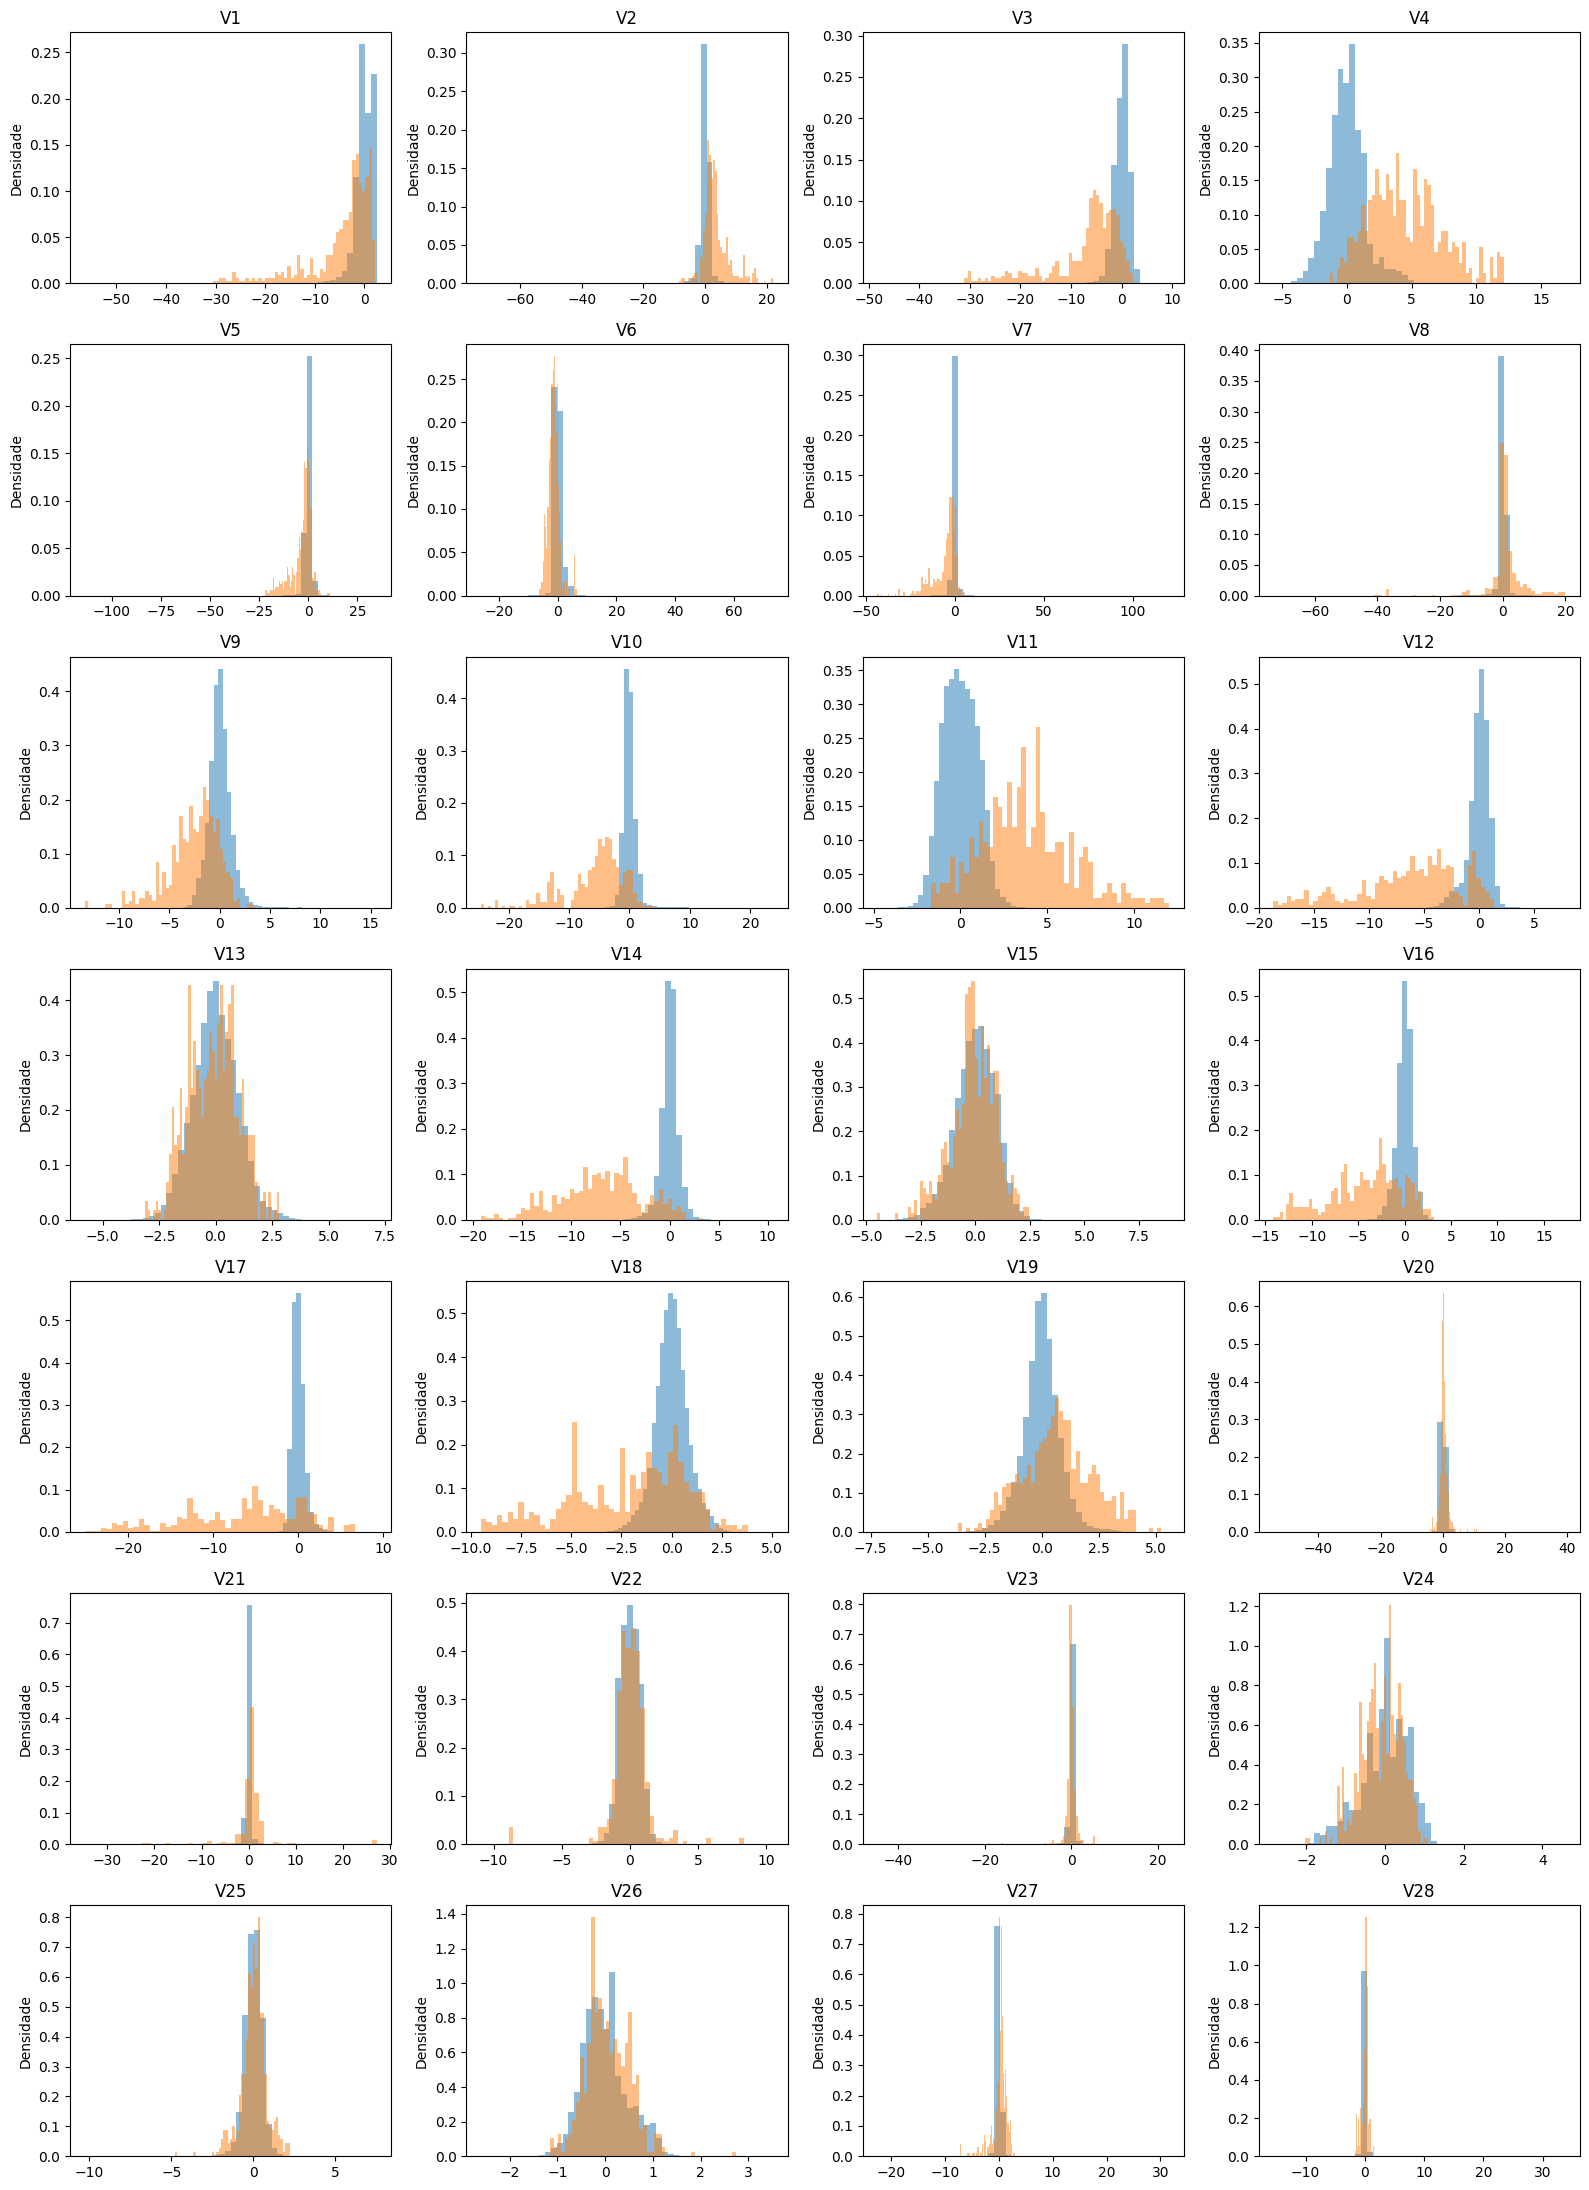

In [ ]:
fig, axes = plt.subplots(
    7,
    4,
    figsize=(16, 22)
)

axes = axes.flatten()

for i, coluna in enumerate(colunas_v):

    axes[i].hist(
        df_legitimas[coluna],
        bins=50,
        density=True,
        alpha=0.5,
        label="Legítima"
    )

    axes[i].hist(
        df_fraudes[coluna],
        bins=50,
        density=True,
        alpha=0.5,
        label="Fraude"
    )

    axes[i].set_title(coluna)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Densidade")

plt.tight_layout()
plt.show()

**Olhe onde as cores se separam.** Em V4 e V11 as fraudes estão deslocadas para a direita; em
V10, V12, V14, V16 e V17, para a esquerda, com uma cauda longa. Já em V13, V15 e de V22 a V28
as duas distribuições praticamente se sobrepõem: essas componentes ajudam pouco a separar
as classes. Como algumas componentes se deslocam para cima e outras para baixo, comparamos também a
**média do valor absoluto**, que mede o quanto cada uma se afasta de zero, em qualquer
direção:

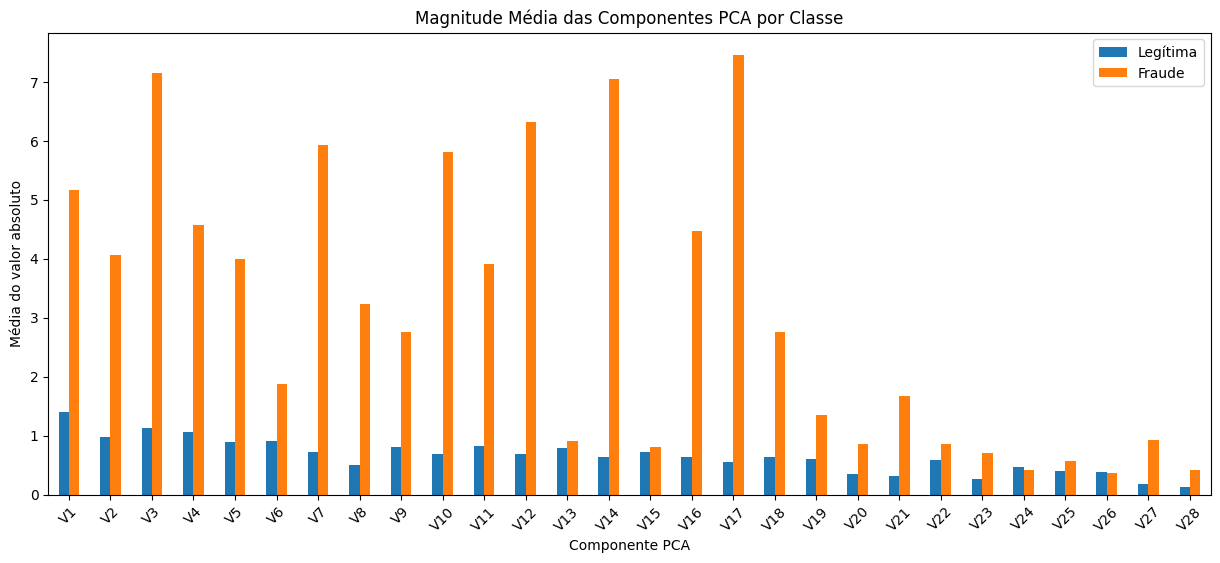

In [ ]:
media_absoluta = pd.DataFrame({
    "Legítima": df_legitimas[colunas_v].abs().mean(),
    "Fraude": df_fraudes[colunas_v].abs().mean()
})

media_absoluta.plot(
    kind="bar",
    figsize=(15, 6)
)

plt.title("Magnitude Média das Componentes PCA por Classe")
plt.xlabel("Componente PCA")
plt.ylabel("Média do valor absoluto")
plt.xticks(rotation=45)

plt.show()

V17, V3 e V14 são as que mais se afastam nas fraudes (acima de 7), seguidas de V12, V7 e V10.
De V22 em diante, as duas classes ficam com magnitudes parecidas. O resultado bate com o
ranking de correlação. O boxplot do `Amount`, agora sem os outliers (`showfliers=False`):

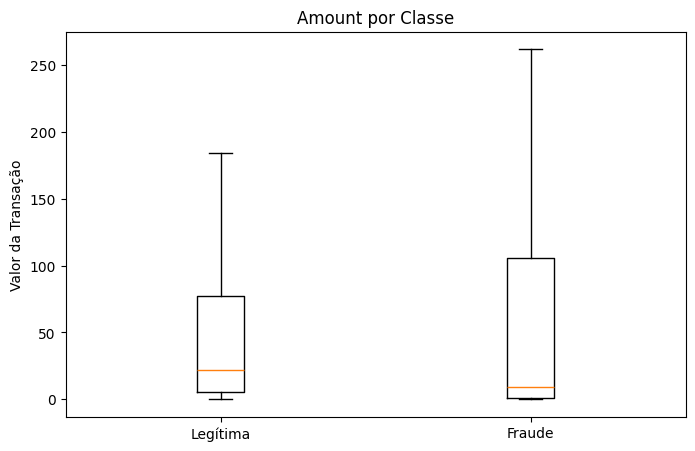

In [ ]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        df_legitimas["Amount"],
        df_fraudes["Amount"]
    ],
    tick_labels=[
        "Legítima",
        "Fraude"
    ],
    showfliers=False
)

plt.title("Amount por Classe")
plt.ylabel("Valor da Transação")

plt.show()

Sem os extremos, a diferença aparece: a mediana das fraudes é menor, mas a caixa vai mais alto
(até cerca de 105, contra 77 das legítimas). As fraudes são mais **espalhadas** no valor. E o horário das duas classes no mesmo gráfico, em horas, com densidade para compará-las na
mesma escala:

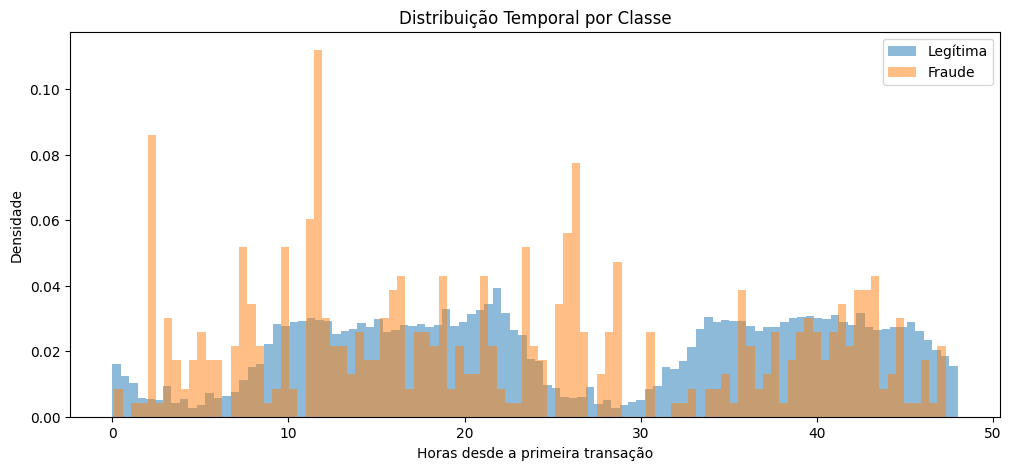

In [ ]:
plt.figure(figsize=(12, 5))

plt.hist(
    df_legitimas["Time"] / 3600,
    bins=100,
    density=True,
    alpha=0.5,
    label="Legítima"
)

plt.hist(
    df_fraudes["Time"] / 3600,
    bins=100,
    density=True,
    alpha=0.5,
    label="Fraude"
)

plt.title("Distribuição Temporal por Classe")
plt.xlabel("Horas desde a primeira transação")
plt.ylabel("Densidade")
plt.legend()

plt.show()

As legítimas seguem um **ciclo de dia e noite**: o volume cai perto das horas 1 a 7 e 25 a 31,
que devem corresponder às madrugadas dos dois dias. As fraudes não seguem esse ciclo: aparecem
em picos isolados, inclusive nas horas de pouco movimento, onde passam a ser uma fração maior
das transações.

---
## Parte 3: Preparação dos dados

Três passos antes de treinar: limpar as duplicadas, dividir em treino, validação e teste, e
colocar `Time` e `Amount` na mesma escala das componentes PCA.

As 1.081 linhas repetidas encontradas na Parte 1 saem agora, antes da divisão, para que a mesma
transação não apareça no treino e no teste ao mesmo tempo.

In [ ]:
df = df.drop_duplicates().reset_index(drop=True)

print(f"Linhas após remover duplicadas: {df.shape[0]}")
print(f"Fraudes após remover duplicadas: {df['Class'].sum()}")

Linhas após remover duplicadas: 283726
Fraudes após remover duplicadas: 473


Sobram **283.726 linhas e 473 fraudes**: das duplicadas removidas, 19 eram fraudes. `X` fica com as 30 colunas de entrada (`Time`, `V1` a `V28` e `Amount`) e `y` com o `Class`.

In [ ]:
X = df.drop(columns=["Class"])
y = df["Class"]

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

Formato de X: (283726, 30)
Formato de y: (283726,)


In [ ]:
X.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99


In [ ]:
y.head()

,Class
0,0
1,0
2,0
3,0
4,0


Treino, validação e teste

A divisão é feita em duas etapas: primeiro 70% para treino e 30% guardados em `X_temp`; depois
esses 30% são divididos ao meio entre validação e teste (15% cada).

O `stratify` é essencial aqui: com só 473 fraudes, uma divisão aleatória simples poderia deixar
um dos conjuntos com poucas fraudes, ou nenhuma. Estratificando, cada conjunto mantém a mesma
proporção de fraudes do total.

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEMENTE,
    stratify=y
)

In [ ]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEMENTE,
    stratify=y_temp
)

In [ ]:
print("Treino:")
print(X_train.shape, y_train.shape)

print("\nValidação:")
print(X_val.shape, y_val.shape)

print("\nTeste:")
print(X_test.shape, y_test.shape)

Treino:
(198608, 30) (198608,)

Validação:
(42559, 30) (42559,)

Teste:
(42559, 30) (42559,)


In [ ]:
print("Fraudes no treino:", y_train.sum())
print("Fraudes na validação:", y_val.sum())
print("Fraudes no teste:", y_test.sum())

Fraudes no treino: 331
Fraudes na validação: 71
Fraudes no teste: 71


São **198.608 amostras de treino e 42.559 de validação e de teste**, com 331, 71 e 71 fraudes.

A validação serve para as escolhas do modelo (early stopping, pesos de classe, limiar); o teste
fica guardado para a medição final.

Uma função para conferir o percentual de fraude em cada conjunto:

In [ ]:
def mostrar_distribuicao(y, nome):
    percentual_fraude = y.mean() * 100

    print(
        f"{nome}: "
        f"{len(y)} amostras | "
        f"{y.sum()} fraudes | "
        f"{percentual_fraude:.4f}% de fraude"
    )

In [ ]:
mostrar_distribuicao(y_train, "Treino")
mostrar_distribuicao(y_val, "Validação")
mostrar_distribuicao(y_test, "Teste")

Treino: 198608 amostras | 331 fraudes | 0.1667% de fraude
Validação: 42559 amostras | 71 fraudes | 0.1668% de fraude
Teste: 42559 amostras | 71 fraudes | 0.1668% de fraude


As componentes `V1` a `V28` já saíram do PCA centradas em zero; `Time` e `Amount`, não. Se entrarem
na rede em escalas tão diferentes, elas dominam os gradientes.

Usamos o `RobustScaler`, que subtrai a mediana e divide pelo intervalo interquartil. Ele é menos
afetado por outliers do que o `StandardScaler`, e a Parte 2 mostrou que o `Amount` tem valores
extremos.

In [ ]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

In [ ]:
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

O scaler é ajustado (`fit`) **só no treino** e depois aplicado (`transform`) aos três conjuntos.
Se o `fit` usasse a validação ou o teste, a mediana e o intervalo carregariam informação desses
conjuntos para o treino: o vazamento de dados.

In [ ]:
colunas_escalar = ["Time", "Amount"]

# Re-instantiate the scaler and fit it only on the desired columns
# to ensure consistency between fit and transform operations.
scaler = RobustScaler()
scaler.fit(X_train[colunas_escalar])

X_train_scaled[colunas_escalar] = scaler.transform(
    X_train[colunas_escalar]
)

X_val_scaled[colunas_escalar] = scaler.transform(
    X_val[colunas_escalar]
)

X_test_scaled[colunas_escalar] = scaler.transform(
    X_test[colunas_escalar]
)

In [ ]:
X_train_scaled.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
256381,0.860849,2.139297,-2.379957,-0.588094,-2.116887,-0.151810,4.930636,-3.133495,1.408309,0.431508,...,-0.379746,-0.073778,0.629693,0.241327,0.738886,-0.314844,0.044060,0.139812,-0.034152,-0.119150
118031,-0.114632,-2.150992,0.447565,0.584405,1.181052,0.180772,-1.200828,-0.106578,0.771604,-1.441208,...,0.028937,-0.066225,-0.869480,-0.041398,0.501689,-0.198083,-0.732049,-0.234089,-0.221309,-0.306346
120210,-0.105008,-6.000510,-5.868708,-1.210423,2.234168,-0.925608,0.019870,0.012067,0.910109,-0.905567,...,0.545803,-0.132715,-0.755490,0.460192,-0.747164,-0.243348,-0.205593,0.915416,-1.136679,7.241772
162381,0.360782,2.021325,-0.535640,-0.416146,-0.124310,-0.178832,0.918878,-1.042599,0.318182,1.072180,...,-0.078728,0.020950,0.209552,0.220896,-0.311931,-0.459092,0.495448,-0.012725,-0.051766,-0.292737
171306,0.423403,0.149536,0.807852,-0.590906,-0.509802,1.145394,-1.116329,0.935687,-0.234237,0.014499,...,-0.122272,0.220651,0.679815,-0.349294,-0.734172,0.185243,-0.114120,0.027129,0.015322,-0.242050


Comparando `Time` e `Amount` antes e depois da escala:

In [ ]:
X_train[["Time", "Amount"]].describe()

,Time,Amount
count,198608.000000,198608.000000
mean,94915.874194,88.321679
std,47485.527892,242.613439
min,0.000000,0.000000
25%,54273.750000,5.700000
50%,84857.000000,22.080000
75%,139372.250000,77.710000
max,172792.000000,18910.000000


In [ ]:
X_train_scaled[["Time", "Amount"]].describe()

,Time,Amount
count,198608.000000,198608.000000
mean,0.118203,0.919896
std,0.558007,3.369163
min,-0.997162,-0.306624
25%,-0.359386,-0.227468
50%,0.000000,0.000000
75%,0.640614,0.772532
max,1.033332,262.295792


Depois da escala, as duas colunas têm **mediana 0** e o intervalo interquartil vira 1 (de −0,36
a 0,64 em `Time`, de −0,23 a 0,77 em `Amount`). O máximo do `Amount` continua alto (262,30): o
`RobustScaler` não corta outliers, só impede que eles definam a escala.

O TensorFlow trabalha em `float32` por padrão. Convertemos entradas e rótulos para evitar
conversões implícitas e gastar metade da memória do `float64`.

In [ ]:
X_train_scaled = X_train_scaled.astype("float32")
X_val_scaled = X_val_scaled.astype("float32")
X_test_scaled = X_test_scaled.astype("float32")

y_train = y_train.astype("float32")
y_val = y_val.astype("float32")
y_test = y_test.astype("float32")

In [ ]:
print(X_train_scaled.dtypes.unique())
print(y_train.dtype)

[dtype('float32')]
float32


---
## Parte 4: Baseline com todas transações legítimas

Antes de treinar modelos mais complexos, é criado um baseline simples que classifica todas as transações como legítimas `(Classe 0)`.

O objetivo desse experimento é demonstrar o efeito do forte desbalanceamento do dataset. Como mais de 99% das transações são legítimas, um modelo que nunca identifica uma fraude ainda consegue obter uma acurácia muito elevada.

In [ ]:
y_pred_baseline = np.zeros(len(y_test))

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_baseline = accuracy_score(
    y_test,
    y_pred_baseline
)

As previsões são comparadas com as classes reais utilizando Accuracy, Precision, Recall e F1-score.

Apesar da Accuracy elevada, Precision, Recall e F1-score são iguais a zero, pois o modelo não identifica nenhuma fraude.

Isso evidencia que, em problemas altamente desbalanceados, um modelo pode apresentar excelente acurácia global e ainda ser completamente inútil para detectar a classe de interesse.

In [ ]:
precision_baseline = precision_score(
    y_test,
    y_pred_baseline,
    zero_division=0
)

recall_baseline = recall_score(
    y_test,
    y_pred_baseline
)

f1_baseline = f1_score(
    y_test,
    y_pred_baseline
)

print(f"Accuracy: {accuracy_baseline:.4f}")
print(f"Precision: {precision_baseline:.4f}")
print(f"Recall:    {recall_baseline:.4f}")
print(f"F1-score:  {f1_baseline:.4f}")

Accuracy: 0.9983
Precision: 0.0000
Recall:    0.0000
F1-score:  0.0000


---
## Parte 5: Arquitetura utilizando MLP: modelo 1

A primeira MLP é utilizada como baseline de rede neural, sem nenhum tratamento específico para o desbalanceamento das classes.

A rede recebe todas as features de entrada e possui três camadas densas com 64, 32 e 16 neurônios, utilizando a função de ativação ReLU.

Após as duas primeiras camadas é aplicado Dropout de 20%, que desativa aleatoriamente parte dos neurônios durante o treinamento com o objetivo de reduzir overfitting.

A camada de saída possui apenas um neurônio com ativação sigmoid, adequada para classificação binária. Ela produz um score entre 0 e 1 associado à probabilidade estimada de fraude.

In [ ]:
modelo_mlp1 = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),

    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),

    layers.Dense(16, activation="relu"),

    layers.Dense(1, activation="sigmoid")
])

In [ ]:
modelo_mlp1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

**Configuração do treinamento**

A rede é treinada utilizando:

* Adam como otimizador, com learning_rate = 0.001;
* Binary Cross-Entropy como função de perda, adequada para classificação binária;
* Precision, Recall e PR-AUC como métricas de acompanhamento.

O PR-AUC recebe atenção especial por ser mais informativo do que Accuracy em um problema com uma classe positiva extremamente rara.

In [ ]:
modelo_mlp1.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="binary_crossentropy",

    metrics=[
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(
            curve="PR",
            name="pr_auc"
        )
    ]
)

Também é utilizado `EarlyStopping`, monitorando o `val_pr_auc`. Caso não haja melhoria durante cinco épocas consecutivas, o treinamento é interrompido e os pesos da melhor época são restaurados.

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_pr_auc",
    mode="max",
    patience=5,
    restore_best_weights=True
)

**Treinamento e acompanhamento**

A rede é treinada utilizando o conjunto de treino, enquanto o conjunto de validação é utilizado apenas para acompanhar a capacidade de generalização.

O treinamento possui no máximo 20 épocas e utiliza batches de 256 observações.

In [ ]:
historico_mlp1 = modelo_mlp1.fit(
    X_train_scaled,
    y_train,

    validation_data=(
        X_val_scaled,
        y_val
    ),

    epochs=20,
    batch_size=256,

    callbacks=[
        early_stopping
    ],

    verbose=1
)

Epoch 1/20
776/776 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0366 - pr_auc: 0.2896 - precision: 0.0693 - recall: 0.4985 - val_loss: 0.0034 - val_pr_auc: 0.7132 - val_precision: 0.8814 - val_recall: 0.7324
Epoch 2/20
776/776 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0039 - pr_auc: 0.7113 - precision: 0.8243 - recall: 0.7372 - val_loss: 0.0032 - val_pr_auc: 0.7287 - val_precision: 0.8730 - val_recall: 0.7746
Epoch 3/20
776/776 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0034 - pr_auc: 0.7330 - precision: 0.8278 - recall: 0.7553 - val_loss: 0.0032 - val_pr_auc: 0.7339 - val_precision: 0.8730 - val_recall: 0.7746
Epoch 4/20
776/776 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0032 - pr_auc: 0.7373 - precision: 0.8366 - recall: 0.7734 - val_loss: 0.0030 - val_pr_auc: 0.7635 - val_precision: 0.8730 - val_recall: 0.7746
Epoch 5/20
776/776 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0029 - pr_auc: 0.7785 - precision: 0.8344 - recall: 0.7764 - val_loss: 0.0031 - val_pr_auc: 0.8020 - val_precision

Os gráficos seguintes mostram a evolução de Loss, Precision, Recall e PR-AUC nos conjuntos de treino e validação. A comparação entre essas curvas permite acompanhar o aprendizado do modelo e identificar possíveis sinais de overfitting.

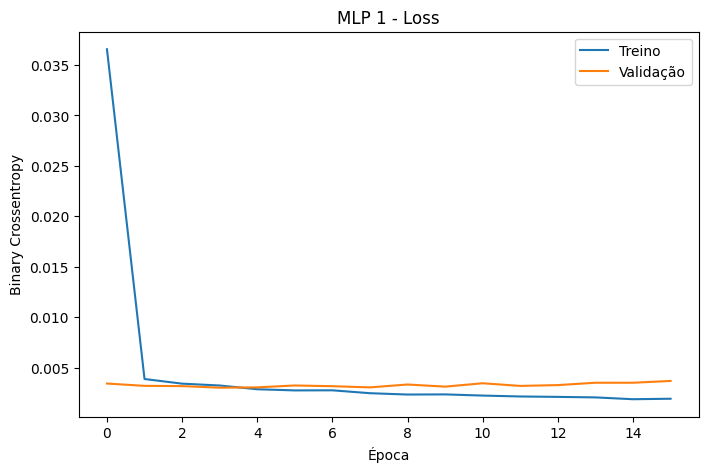

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    historico_mlp1.history["loss"],
    label="Treino"
)

plt.plot(
    historico_mlp1.history["val_loss"],
    label="Validação"
)

plt.title("MLP 1 - Loss")
plt.xlabel("Época")
plt.ylabel("Binary Crossentropy")
plt.legend()

plt.show()

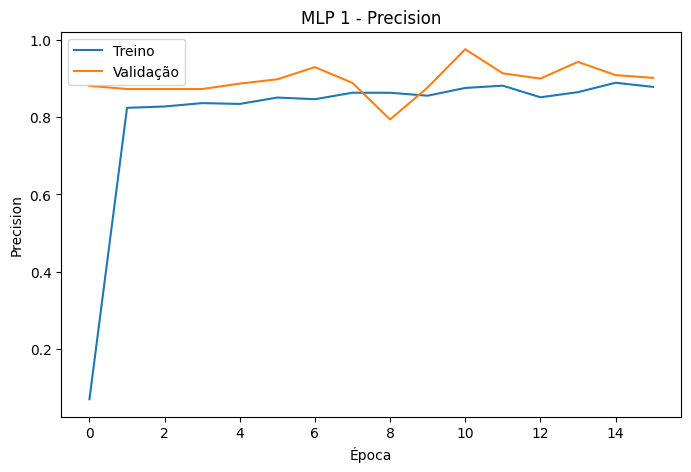

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    historico_mlp1.history["precision"],
    label="Treino"
)

plt.plot(
    historico_mlp1.history["val_precision"],
    label="Validação"
)

plt.title("MLP 1 - Precision")
plt.xlabel("Época")
plt.ylabel("Precision")
plt.legend()

plt.show()

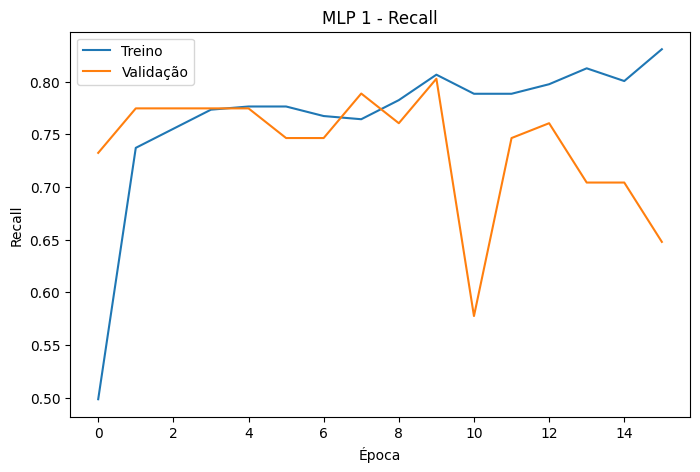

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    historico_mlp1.history["recall"],
    label="Treino"
)

plt.plot(
    historico_mlp1.history["val_recall"],
    label="Validação"
)

plt.title("MLP 1 - Recall")
plt.xlabel("Época")
plt.ylabel("Recall")
plt.legend()

plt.show()

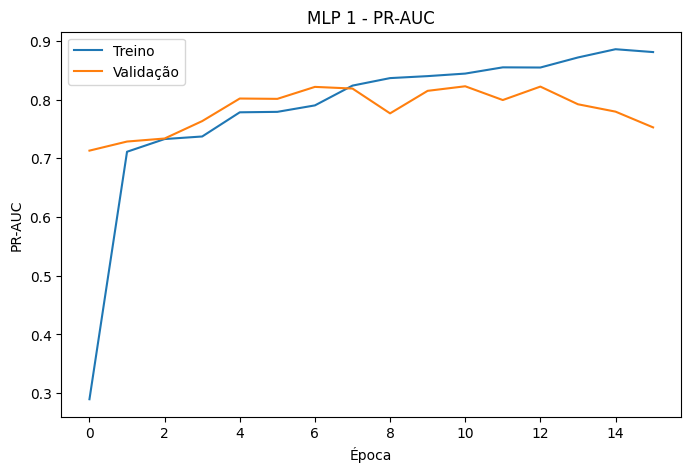

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    historico_mlp1.history["pr_auc"],
    label="Treino"
)

plt.plot(
    historico_mlp1.history["val_pr_auc"],
    label="Validação"
)

plt.title("MLP 1 - PR-AUC")
plt.xlabel("Época")
plt.ylabel("PR-AUC")
plt.legend()

plt.show()

**Avaliação da MLP 1**

Após o treinamento, a rede gera um score entre 0 e 1 para cada observação do conjunto de validação.

Para obter uma classificação binária, é utilizado inicialmente um threshold de 0,5:

* score < 0,5 → transação legítima;
* score ≥ 0,5 → fraude.

Esse valor é utilizado como referência inicial e não representa necessariamente o melhor limiar operacional para o problema.

In [ ]:
y_score_mlp1 = modelo_mlp1.predict(
    X_val_scaled
).ravel()

1330/1330 ━━━━━━━━━━━━━━━━━━━━ 1s 718us/step


In [ ]:
y_pred_mlp1 = (
    y_score_mlp1 >= 0.5
).astype(int)

Accuracy, Precision, Recall e F1-score são calculados utilizando as classes geradas pelo threshold. Já o PR-AUC utiliza diretamente os scores produzidos pela rede, avaliando o comportamento do modelo ao longo de diferentes limiares.

In [ ]:
accuracy_mlp1 = accuracy_score(
    y_val,
    y_pred_mlp1
)

precision_mlp1 = precision_score(
    y_val,
    y_pred_mlp1,
    zero_division=0
)

recall_mlp1 = recall_score(
    y_val,
    y_pred_mlp1,
    zero_division=0
)

f1_mlp1 = f1_score(
    y_val,
    y_pred_mlp1,
    zero_division=0
)

pr_auc_mlp1 = average_precision_score(
    y_val,
    y_score_mlp1
)

print(f"Accuracy:  {accuracy_mlp1:.4f}")
print(f"Precision: {precision_mlp1:.4f}")
print(f"Recall:    {recall_mlp1:.4f}")
print(f"F1-score:  {f1_mlp1:.4f}")
print(f"PR-AUC:    {pr_auc_mlp1:.4f}")

Accuracy:  0.9993
Precision: 0.9762
Recall:    0.5775
F1-score:  0.7257
PR-AUC:    0.8273


---
## Parte 6: Arquitetura usando MLP: modelo 2

A segunda MLP utiliza a mesma arquitetura e os mesmos hiperparâmetros principais da MLP 1. A diferença está na utilização de **pesos diferentes para as classes** durante o treinamento.

O objetivo é avaliar se aumentar a importância dos erros cometidos sobre a classe minoritária melhora a capacidade do modelo de identificar fraudes.

Foi utilizado:

* classe legítima (0): peso 1;
* fraude (1): peso 5.

Isso significa que um erro envolvendo uma fraude possui aproximadamente cinco vezes mais influência na função de perda do que um erro envolvendo uma transação legítima.

O `class_weight` não cria novas observações nem duplica fraudes. Ele apenas altera a contribuição de cada classe para a função de perda durante o treinamento.

In [ ]:
class_weight_mlp2 = {
    0: 1.0,
    1: 5.0
}

print(class_weight_mlp2)

{0: 1.0, 1: 5.0}


A arquitetura permanece com camadas de 64, 32 e 16 neurônios, ReLU, Dropout de 20% e saída sigmoid.

In [ ]:
modelo_mlp2 = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),

    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),

    layers.Dense(16, activation="relu"),

    layers.Dense(1, activation="sigmoid")
])

Também são mantidos Adam, Binary Cross-Entropy, learning rate de 0.001, batch size de 256 e Early Stopping baseado no PR-AUC de validação.

In [ ]:
modelo_mlp2.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="binary_crossentropy",

    metrics=[
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(
            curve="PR",
            name="pr_auc"
        )
    ]
)

In [ ]:
early_stopping_mlp2 = keras.callbacks.EarlyStopping(
    monitor="val_pr_auc",
    mode="max",
    patience=5,
    restore_best_weights=True
)

A principal mudança em relação à MLP 1 é a inclusão de:

`class_weight = {0: 1, 1: 5}`

Manter as demais configurações semelhantes torna possível observar com maior clareza o efeito da ponderação das classes.

In [ ]:
historico_mlp2 = modelo_mlp2.fit(
    X_train_scaled,
    y_train,

    validation_data=(
        X_val_scaled,
        y_val
    ),

    epochs=20,
    batch_size=256,

    class_weight=class_weight_mlp2,

    callbacks=[
        early_stopping_mlp2
    ],

    verbose=1
)

Epoch 1/20
776/776 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0289 - pr_auc: 0.5382 - precision: 0.6842 - recall: 0.6284 - val_loss: 0.0052 - val_pr_auc: 0.7050 - val_precision: 0.8143 - val_recall: 0.8028
Epoch 2/20
776/776 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0116 - pr_auc: 0.7056 - precision: 0.7719 - recall: 0.7976 - val_loss: 0.0047 - val_pr_auc: 0.7101 - val_precision: 0.8056 - val_recall: 0.8169
Epoch 3/20
776/776 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0102 - pr_auc: 0.7328 - precision: 0.7521 - recall: 0.7976 - val_loss: 0.0045 - val_pr_auc: 0.7095 - val_precision: 0.7160 - val_recall: 0.8169
Epoch 4/20
776/776 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0100 - pr_auc: 0.7496 - precision: 0.7642 - recall: 0.8127 - val_loss: 0.0053 - val_pr_auc: 0.7088 - val_precision: 0.6824 - val_recall: 0.8169
Epoch 5/20
776/776 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0085 - pr_auc: 0.7744 - precision: 0.7692 - recall: 0.8459 - val_loss: 0.0038 - val_pr_auc: 0.7542 - val_precision

**Avaliação da MLP 2**

Assim como na MLP 1, o modelo gera scores de fraude para o conjunto de validação e utiliza inicialmente `threshold de 0,5` para transformá-los em classes.

São calculadas as mesmas métricas para permitir uma comparação direta entre os dois modelos.

In [ ]:
y_score_mlp2 = modelo_mlp2.predict(
    X_val_scaled
).ravel()

y_pred_mlp2 = (
    y_score_mlp2 >= 0.5
).astype(int)

1330/1330 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [ ]:
accuracy_mlp2 = accuracy_score(
    y_val,
    y_pred_mlp2
)

precision_mlp2 = precision_score(
    y_val,
    y_pred_mlp2,
    zero_division=0
)

recall_mlp2 = recall_score(
    y_val,
    y_pred_mlp2,
    zero_division=0
)

f1_mlp2 = f1_score(
    y_val,
    y_pred_mlp2,
    zero_division=0
)

pr_auc_mlp2 = average_precision_score(
    y_val,
    y_score_mlp2
)

print(f"Accuracy:  {accuracy_mlp2:.4f}")
print(f"Precision: {precision_mlp2:.4f}")
print(f"Recall:    {recall_mlp2:.4f}")
print(f"F1-score:  {f1_mlp2:.4f}")
print(f"PR-AUC:    {pr_auc_mlp2:.4f}")

Accuracy:  0.9994
Precision: 0.8169
Recall:    0.8169
F1-score:  0.8169
PR-AUC:    0.8259


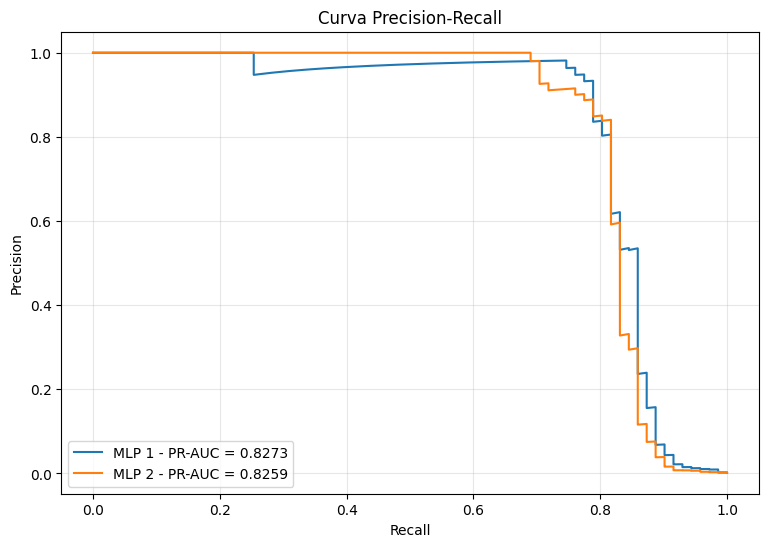

In [ ]:
from sklearn.metrics import precision_recall_curve

precision1, recall1, thresholds1 = precision_recall_curve(
    y_val,
    y_score_mlp1
)

precision2, recall2, thresholds2 = precision_recall_curve(
    y_val,
    y_score_mlp2
)

plt.figure(figsize=(9, 6))

plt.plot(
    recall1,
    precision1,
    label=f"MLP 1 - PR-AUC = {pr_auc_mlp1:.4f}"
)

plt.plot(
    recall2,
    precision2,
    label=f"MLP 2 - PR-AUC = {pr_auc_mlp2:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
def avaliar_thresholds(y_real, y_score, thresholds):
    resultados = []

    for threshold in thresholds:
        y_pred = (y_score >= threshold).astype(int)

        precision = precision_score(
            y_real,
            y_pred,
            zero_division=0
        )

        recall = recall_score(
            y_real,
            y_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_real,
            y_pred,
            zero_division=0
        )

        tn, fp, fn, tp = confusion_matrix(
            y_real,
            y_pred
        ).ravel()

        resultados.append({
            "Threshold": threshold,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "TN": tn
        })

    return pd.DataFrame(resultados)

In [ ]:
thresholds_teste = np.arange(
    0.10,
    0.91,
    0.05
)

resultados_threshold_mlp1 = avaliar_thresholds(
    y_val,
    y_score_mlp1,
    thresholds_teste
)

display(resultados_threshold_mlp1)

,Threshold,Precision,Recall,F1,TP,FP,FN,TN
0,0.10,0.734177,0.816901,0.773333,58,21,13,42467
1,0.15,0.773333,0.816901,0.794521,58,17,13,42471
2,0.20,0.802817,0.802817,0.802817,57,14,14,42474
3,0.25,0.838235,0.802817,0.820144,57,11,14,42477
4,0.30,0.835821,0.788732,0.811594,56,11,15,42477
5,0.35,0.861538,0.788732,0.823529,56,9,15,42479
6,0.40,0.875000,0.788732,0.829630,56,8,15,42480
7,0.45,0.918033,0.788732,0.848485,56,5,15,42483
8,0.50,0.976190,0.577465,0.725664,41,1,30,42487
9,0.55,0.967742,0.422535,0.588235,30,1,41,42487


In [ ]:
resultados_threshold_mlp2 = avaliar_thresholds(
    y_val,
    y_score_mlp2,
    thresholds_teste
)

display(resultados_threshold_mlp2)

,Threshold,Precision,Recall,F1,TP,FP,FN,TN
0,0.10,0.551402,0.830986,0.662921,59,48,12,42440
1,0.15,0.623656,0.816901,0.707317,58,35,13,42453
2,0.20,0.674419,0.816901,0.738854,58,28,13,42460
3,0.25,0.707317,0.816901,0.758170,58,24,13,42464
4,0.30,0.743590,0.816901,0.778523,58,20,13,42468
5,0.35,0.773333,0.816901,0.794521,58,17,13,42471
6,0.40,0.783784,0.816901,0.800000,58,16,13,42472
7,0.45,0.805556,0.816901,0.811189,58,14,13,42474
8,0.50,0.816901,0.816901,0.816901,58,13,13,42475
9,0.55,0.828571,0.816901,0.822695,58,12,13,42476


In [ ]:
melhor_linha_mlp1 = resultados_threshold_mlp1.loc[
    resultados_threshold_mlp1["F1"].idxmax()
]

melhor_linha_mlp1

,7
Threshold,0.450000
Precision,0.918033
Recall,0.788732
F1,0.848485
TP,56.000000
FP,5.000000
FN,15.000000
TN,42483.000000


In [ ]:
melhor_linha_mlp2 = resultados_threshold_mlp2.loc[
    resultados_threshold_mlp2["F1"].idxmax()
]

melhor_linha_mlp2

,13
Threshold,0.750000
Precision,0.901639
Recall,0.774648
F1,0.833333
TP,55.000000
FP,6.000000
FN,16.000000
TN,42482.000000


**Comparação com a MLP 1**

A ponderação alterou significativamente o equilíbrio entre Precision e Recall.

A **MLP 1** apresentou comportamento mais conservador, com Precision elevada, mas Recall menor. Já a **MLP 2** aumentou o Recall, conseguindo identificar uma proporção maior das fraudes existentes, ao custo de uma redução na Precision.

Esse resultado evidencia o principal trade-off do problema:

aumentar a sensibilidade às fraudes tende a identificar mais casos positivos, mas também pode aumentar a quantidade de transações legítimas classificadas incorretamente como fraude.

O PR-AUC dos dois modelos permaneceu próximo, indicando que ambos possuem capacidade semelhante de ordenação das transações por risco. A principal diferença está no comportamento obtido com o limiar de decisão utilizado.

## Parte 7: Baseline com árvores

Além do baseline simples, utilizamos um modelo baseado em árvores como referência para comparação com as redes neurais.

O HistGradientBoosting é um algoritmo baseado em árvores de decisão construídas de forma sequencial. A cada etapa, novas árvores procuram corrigir os erros cometidos pelas anteriores. Esse tipo de modelo é adequado para dados tabulares e permite verificar se a maior complexidade de uma rede neural realmente traz benefícios para o problema de detecção de fraudes.

Como o conjunto de dados é extremamente desbalanceado, não é adequado avaliar os modelos apenas pela acurácia. Um modelo que classifique praticamente todas as transações como legítimas pode apresentar alta acurácia e, ao mesmo tempo, deixar passar grande parte das fraudes.

O `HistGradientBoostingClassifier` com 300 árvores e taxa de 0,05. Os rótulos voltam para
`int`, porque foram convertidos para `float32` anteriormente.

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

# Inicializa o modelo HistGradientBoostingClassifier com parâmetros específicos:
# max_iter: número máximo de iterações (árvores)
# learning_rate: taxa de aprendizado, controlando a contribuição de cada árvore
modelo_hgb = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.05,
    random_state=SEMENTE
)

# Treina o modelo utilizando os dados de treino escalados (X_train_scaled)
# e os rótulos de treino convertidos para inteiro
modelo_hgb.fit(
    X_train_scaled,
    y_train.astype(int)
)

HistGradientBoostingClassifier(learning_rate=0.05, max_iter=300,
                               random_state=42)

In [ ]:
# Gera as pontuações de probabilidade de fraude para o conjunto de validação (X_val_scaled).
# predict_proba retorna as probabilidades para ambas as classes e [:, 1] seleciona a classe 1.
y_score_hgb = modelo_hgb.predict_proba(
    X_val_scaled
)[:, 1]

# Calcula o PR-AUC (Area Under the Precision-Recall Curve) para o modelo HGB.
# O PR-AUC é uma métrica crucial para datasets desbalanceados, como este de fraude,
# pois foca na performance das classes positivas (fraudes).
pr_auc_hgb = average_precision_score(
    y_val,
    y_score_hgb
)

print(f"PR-AUC HGB: {pr_auc_hgb:.4f}")

PR-AUC HGB: 0.5650


A PR-AUC do HGB na validação é **0,5650**, bem abaixo das duas MLPs (cerca de 0,83).

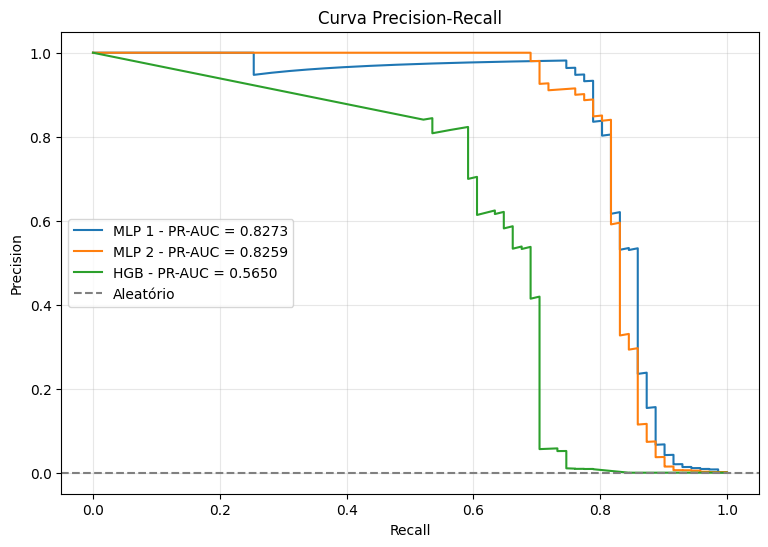

In [ ]:
# Calcula a curva Precision-Recall para o modelo HistGradientBoostingClassifier.
# Esta função retorna três arrays: precisões, recalls e thresholds.
precision3, recall3, thresholds3 = precision_recall_curve(
    y_val,
    y_score_hgb
)

plt.figure(figsize=(9, 6))

# Plota a curva Precision-Recall para o MLP 1.
plt.plot(recall1, precision1, label=f"MLP 1 - PR-AUC = {pr_auc_mlp1:.4f}")
# Plota a curva Precision-Recall para o MLP 2.
plt.plot(recall2, precision2, label=f"MLP 2 - PR-AUC = {pr_auc_mlp2:.4f}")
# Plota a curva Precision-Recall para o HGB.
plt.plot(recall3, precision3, label=f"HGB - PR-AUC = {pr_auc_hgb:.4f}")

# Adiciona uma linha horizontal pontilhada representando uma baseline aleatória.
# Para um conjunto de dados desbalanceado, a precision de um classificador aleatório
# é igual à proporção da classe positiva (fraudes) no dataset.
plt.axhline(y_val.mean(), linestyle="--", color="gray", label="Aleatório")


plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

A curva do HGB (verde) fica abaixo das duas MLPs em quase toda a faixa de recall. A linha
tracejada é o classificador aleatório: a precisão dele é a proporção de fraudes, perto de zero.

---
## Parte 8: Limiar por custo

Os modelos retornam uma pontuação ou probabilidade associada à classe de fraude. Para transformar essa pontuação em uma decisão final, é necessário definir um limiar (threshold).

Em vez de utilizar automaticamente o valor padrão de 0.5, diferentes limiares são avaliados. Para cada limiar, são calculados os falsos positivos (FP) e falsos negativos (FN).

O custo total de cada limiar é calculado por:
Custo = (CUSTO_FN * Falsos Negativos) + (CUSTO_FP * Falsos Positivos)

Dessa forma, deixar uma fraude passar é considerado 20 vezes mais custoso do que bloquear incorretamente uma transação legítima.

Os custos: **100 por fraude liberada** e **5 por compra legítima bloqueada**. A mesma
`avaliar_thresholds` roda para o HGB, e cada tabela ganha a coluna `Custo`.

In [ ]:
CUSTO_FN = 100  # Custo de um Falso Negativo (fraude não detectada)
CUSTO_FP = 5    # Custo de um Falso Positivo (transação legítima bloqueada)

# Avalia os thresholds para o modelo HistGradientBoosting e armazena os resultados
resultados_threshold_hgb = avaliar_thresholds(
    y_val,
    y_score_hgb,
    thresholds_teste
)

# Itera sobre os resultados de thresholds de todos os modelos (MLP1, MLP2, HGB)
# e calcula o custo total para cada cenário de threshold.
for resultados in [
    resultados_threshold_mlp1,
    resultados_threshold_mlp2,
    resultados_threshold_hgb
]:
    # A fórmula de custo
    resultados["Custo"] = (
        CUSTO_FN * resultados["FN"]
        + CUSTO_FP * resultados["FP"]
    )

O limiar de menor custo de cada modelo:

In [ ]:
# Encontra o threshold com o menor custo para MLP 1
melhor_custo_mlp1 = resultados_threshold_mlp1.loc[resultados_threshold_mlp1["Custo"].idxmin()]
# Encontra o threshold com o menor custo para MLP 2
melhor_custo_mlp2 = resultados_threshold_mlp2.loc[resultados_threshold_mlp2["Custo"].idxmin()]
# Encontra o threshold com o menor custo para HGB
melhor_custo_hgb = resultados_threshold_hgb.loc[resultados_threshold_hgb["Custo"].idxmin()]

# Melhores custos para cada modelo em um DataFrame
display(pd.DataFrame(
    [melhor_custo_mlp1, melhor_custo_mlp2, melhor_custo_hgb],
    index=["MLP 1", "MLP 2", "HGB"]
))

,Threshold,Precision,Recall,F1,TP,FP,FN,TN,Custo
MLP 1,0.15,0.773333,0.816901,0.794521,58.0,17.0,13.0,42471.0,1385.0
MLP 2,0.55,0.828571,0.816901,0.822695,58.0,12.0,13.0,42476.0,1360.0
HGB,0.85,0.538462,0.690141,0.604938,49.0,42.0,22.0,42446.0,2410.0


Na validação, a **MLP 2 com limiar 0,55** tem o menor custo (1.360), seguida de perto pela MLP 1
com 0,15 (1.385). O HGB custa quase o dobro (2.410).

Repare que o limiar de menor custo não é o de maior F1: como a fraude liberada pesa 20 vezes
mais, o custo prefere limiares que aumentam o recall.

O limiar escolhido é aquele que apresenta o menor custo total no conjunto de validação. Assim, a decisão não é baseada somente em métricas tradicionais, mas também no impacto que os erros podem representar para o negócio.

---
## Parte 9: Experimentos

Para variar um hiperparâmetro de cada vez, a célula abaixo define três funções:

- `criar_modelo_mlp`: a mesma MLP das Partes 5 e 6, com o tamanho da primeira camada
  (`n_oculta`) e o dropout ajustáveis; as camadas seguintes são metade e um quarto dela;
- `treinar_tf`: monta, compila e treina a rede com os hiperparâmetros recebidos e devolve o
  histórico de perda, acurácia, AUC-PR e precisão;
- `comparar`: treina uma rede para cada valor do parâmetro testado, desenha a perda de treino e
  a AUC-PR por época, e imprime a última época de cada uma.

Se nada for dito, os experimentos usam os pesos da MLP 2 (1:5), lote de 2048 e 30 épocas.

> **Atenção.** O `treinar_tf` usa `X_test_scaled` como `validation_data`, ou seja, os
> experimentos são comparados no **conjunto de teste**. O correto seria usar a validação e
> guardar o teste só para a Parte 11.

In [ ]:
import time
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# 1. O Molde da sua MLP continua igual
def criar_modelo_mlp(input_shape, n_oculta=64, p_dropout=0.2):
    l2 = max(n_oculta // 2, 4)
    l3 = max(n_oculta // 4, 2)

    modelo = keras.Sequential([
        layers.Input(shape=(input_shape,)),
        layers.Dense(n_oculta, activation="relu"),
        layers.Dropout(p_dropout),
        layers.Dense(l2, activation="relu"),
        layers.Dropout(p_dropout),
        layers.Dense(l3, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])
    return modelo

# 2. Atualização: Adicionada a métrica Precision
def treinar_tf(taxa=0.001, otimizador="adam", tamanho_lote=2048, epocas=30,
               n_oculta=64, p_dropout=0.2, n_treino=None, class_weight=None, semente=42,verbose=0):

    tf.keras.utils.set_random_seed(semente)

    Xt = X_train_scaled if n_treino is None else X_train_scaled[:n_treino]
    yt = y_train if n_treino is None else y_train[:n_treino]

    input_shape = Xt.shape[1]
    modelo = criar_modelo_mlp(input_shape, n_oculta=n_oculta, p_dropout=p_dropout)

    otimizadores = {
        "adam": tf.keras.optimizers.Adam,
        "sgd": tf.keras.optimizers.SGD,
        "rmsprop": tf.keras.optimizers.RMSprop,
        "adagrad": tf.keras.optimizers.Adagrad
    }

    # ADICIONADO: tf.keras.metrics.Precision()
    modelo.compile(
        optimizer=otimizadores[otimizador.lower()](learning_rate=taxa),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name='auc_pr', curve='PR'),
            tf.keras.metrics.Precision(name='precision')
        ]
    )

    registro = modelo.fit(
        Xt, yt,
        validation_data=(X_test_scaled, y_test),
        epochs=epocas,
        batch_size=tamanho_lote,
        class_weight=class_weight,
        verbose=0
    )

    # ADICIONADO: Capturando a Precision de treino e teste
    historico = {
        "perda_treino": registro.history["loss"],
        "perda_teste": registro.history["val_loss"],
        "acc_treino": registro.history["accuracy"],
        "acc_teste": registro.history["val_accuracy"],
        "auc_pr_treino": registro.history["auc_pr"],
        "auc_pr_teste": registro.history["val_auc_pr"],
        "prec_treino": registro.history["precision"],
        "prec_teste": registro.history["val_precision"]
    }
    return modelo, historico

# 3. Atualização: Tabela final com as 3 métricas
def comparar(parametro, valores, **fixos):
    fig, (esq, dir) = plt.subplots(1, 2, figsize=(11, 3.8))
    resumo = []

    for valor in valores:
        if "class_weight" not in fixos:
            fixos["class_weight"] = {0: 1.0, 1: 5.0}

        _, h = treinar_tf(**{parametro: valor}, **fixos)
        esq.plot(h["perda_treino"], label=f"{parametro}={valor}")

        # Mantemos o gráfico focado em AUC-PR por ser a melhor métrica visual para fraudes
        dir.plot(h["auc_pr_teste"], label=f"{parametro}={valor}")

        # Guardando todos os valores da última época
        resumo.append((
            valor,
            h["perda_treino"][-1],
            h["acc_teste"][-1],
            h["auc_pr_teste"][-1],
            h["prec_teste"][-1]
        ))

    esq.set_xlabel("época")
    esq.set_ylabel("perda de treino")
    esq.legend(fontsize=8)

    dir.set_xlabel("época")
    dir.set_ylabel("AUC-PR em teste")
    dir.legend(fontsize=8)

    fig.suptitle(f"Efeito de: {parametro} (com pesos da MLP2)")
    plt.tight_layout()
    plt.show()

    # Tabela formatada com todas as métricas solicitadas
    print(f"{parametro:>15} | perda treino | acurácia | AUC-PR | precision")
    for valor, perda, acc, auc, prec in resumo:
        print(f"{str(valor):>15} | {perda:12.4f} | {acc:8.4f} | {auc:6.4f} | {prec:9.4f}")

### Experimento 1: taxa de aprendizado

Quatro taxas, de 0,0001 a 0,1, multiplicando por 10:

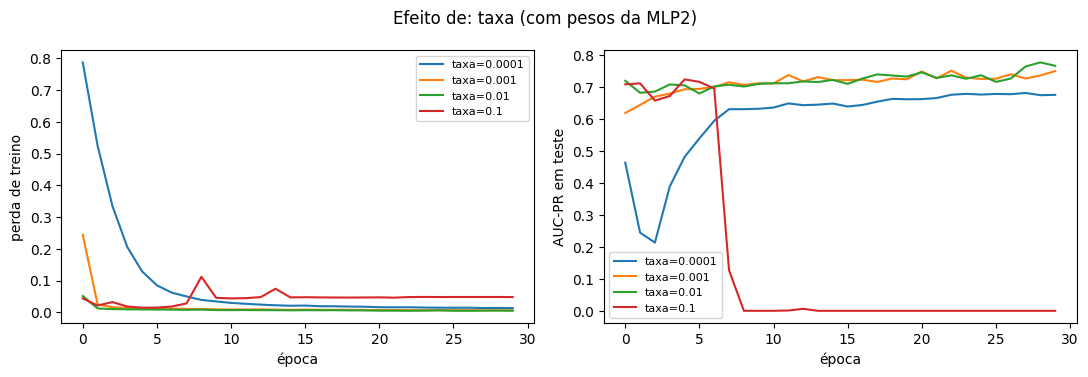

           taxa | perda treino | acurácia | AUC-PR | precision
         0.0001 |       0.0134 |   0.9993 | 0.6763 |    0.7778
          0.001 |       0.0062 |   0.9992 | 0.7507 |    0.7568
           0.01 |       0.0051 |   0.9992 | 0.7672 |    0.7671
            0.1 |       0.0481 |   0.9983 | 0.0017 |    0.0000


In [ ]:
comparar("taxa", [0.0001, 0.001, 0.01, 0.1])

- **0,0001**: a perda cai devagar e a AUC-PR para em 0,6763. Aprende, mas lento demais para 30
  épocas.
- **0,001 e 0,01**: as duas funcionam; 0,01 termina um pouco acima (0,7672 contra 0,7507).
- **0,1**: a AUC-PR vai bem até a época 6 e **desaba para zero**; a precisão final é 0. Os passos
  grandes demais fazem a rede passar a prever só "legítima": a acurácia de 0,9983 é exatamente a
  do baseline trivial.

### Experimento 2: Otimizador

Os quatro otimizadores, primeiro com taxa 0,01 e depois com 0,1:

--- Taxa de 0.01 ---


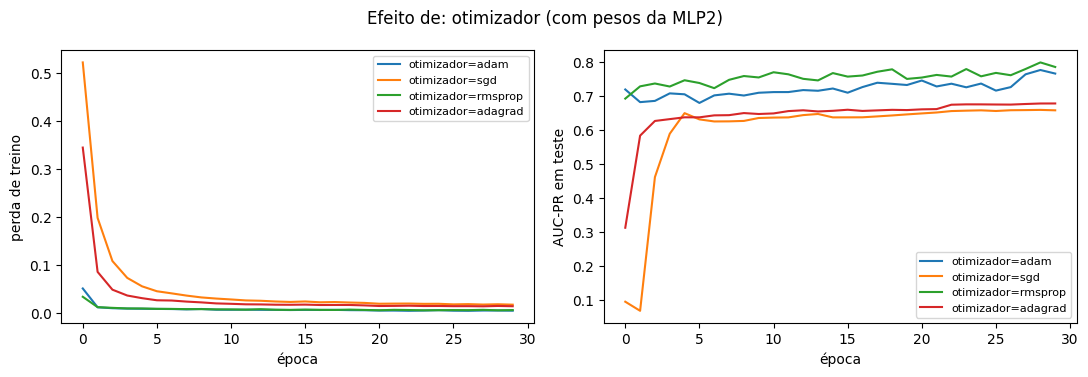

     otimizador | perda treino | acurácia | AUC-PR | precision
           adam |       0.0051 |   0.9992 | 0.7672 |    0.7671
            sgd |       0.0177 |   0.9993 | 0.6588 |    0.8209
        rmsprop |       0.0064 |   0.9993 | 0.7866 |    0.7857
        adagrad |       0.0144 |   0.9993 | 0.6790 |    0.7887

--- Taxa de 0.1 ---


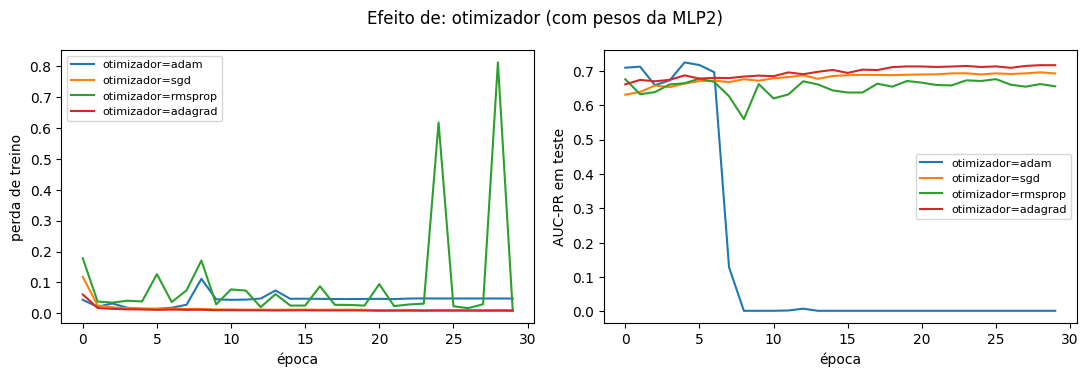

     otimizador | perda treino | acurácia | AUC-PR | precision
           adam |       0.0481 |   0.9983 | 0.0017 |    0.0000
            sgd |       0.0107 |   0.9993 | 0.6924 |    0.7778
        rmsprop |       0.0110 |   0.9993 | 0.6551 |    0.8182
        adagrad |       0.0085 |   0.9993 | 0.7165 |    0.7887


In [ ]:
print("--- Taxa de 0.01 ---")
comparar("otimizador", ["adam", "sgd", "rmsprop", "adagrad"], taxa=0.01)

print("\n--- Taxa de 0.1 ---")
comparar("otimizador", ["adam", "sgd", "rmsprop", "adagrad"], taxa=0.1)

- Com **0,01**, o RMSprop tem a melhor AUC-PR (0,7866), seguido do Adam (0,7672). SGD e
  Adagrad ficam abaixo de 0,68: com essa taxa, eles andam devagar demais.
- Com **0,1**, o quadro se inverte: o Adam desaba (AUC-PR 0,0017), enquanto SGD e Adagrad
  melhoram e o Adagrad fica com a maior AUC-PR (0,7165).

A taxa ideal depende do otimizador: o Adam já adapta o passo de cada peso e fica instável com
taxa alta, enquanto o SGD precisa de uma taxa maior para chegar a algum lugar.

### Experimento 3: Tamanho do Lote (Batch Size)

Cinco tamanhos de lote, do pequeno (32) ao conjunto de treino inteiro, medindo também o tempo
de cada treino:

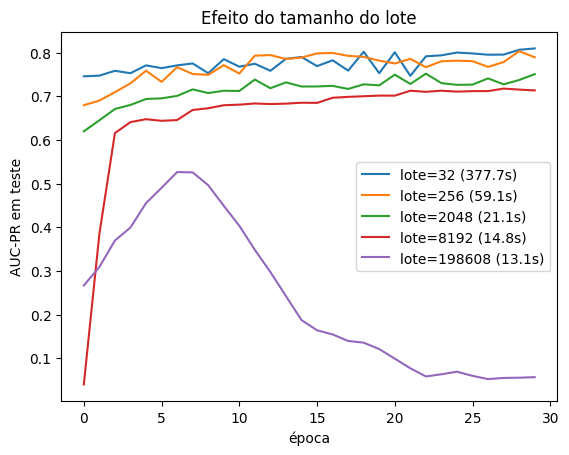

In [ ]:
# Tamanhos adaptados para não estourar a RAM, variando do minúsculo ao gigante
for tamanho in [32, 256, 2048, 8192, len(X_train_scaled)]:
    inicio = time.time()
    # Usando os pesos da sua MLP2
    _, h = treinar_tf(tamanho_lote=tamanho, epocas=30, class_weight={0: 1.0, 1: 5.0})
    duracao = time.time() - inicio
    plt.plot(h["auc_pr_teste"], label=f"lote={tamanho} ({duracao:.1f}s)")

plt.xlabel("época"); plt.ylabel("AUC-PR em teste")
plt.legend(); plt.title("Efeito do tamanho do lote")
plt.show()

- **Lotes pequenos (32 e 256)** chegam à maior AUC-PR, perto de 0,8, mas são os mais lentos:
  377,7 s e 59,1 s.
- **Lotes grandes (2048 e 8192)** são mais rápidos e param mais baixo (cerca de 0,75 e 0,71).
- **O lote do tamanho do treino inteiro** faz um único passo por época: a AUC-PR sobe até perto
  de 0,53 e depois despenca para perto de 0,05.

Com 0,17% de fraudes, lotes menores dão mais passos de atualização por época, e cada passo tem
mais chance de trazer o sinal das poucas fraudes.

### Experimento 4: Tamanho da Rede (Camadas Ocultas)

Quatro tamanhos para a primeira camada oculta (as outras duas acompanham):

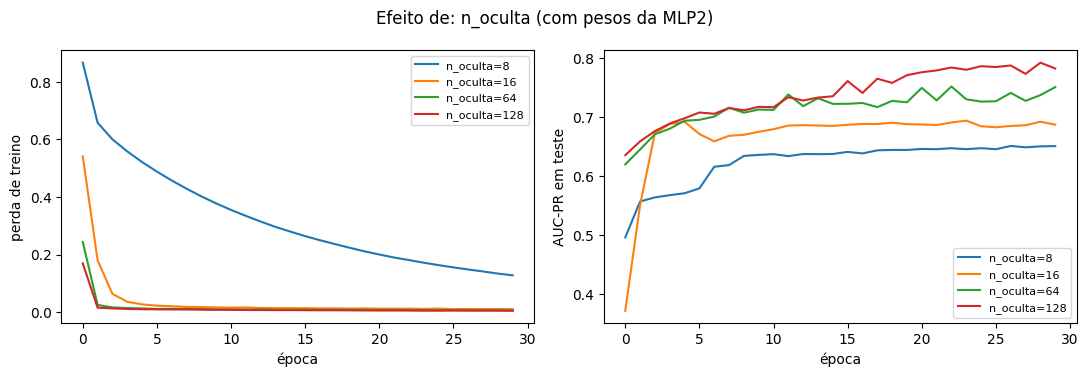

       n_oculta | perda treino | acurácia | AUC-PR | precision
              8 |       0.1277 |   0.9994 | 0.6506 |    0.8438
             16 |       0.0103 |   0.9993 | 0.6871 |    0.8000
             64 |       0.0062 |   0.9992 | 0.7507 |    0.7568
            128 |       0.0044 |   0.9991 | 0.7823 |    0.7179


In [ ]:
comparar("n_oculta", [8, 16, 64, 128])

Quanto maior a rede, menor a perda de treino e maior a AUC-PR (de 0,6506 com 8 neurônios a
0,7823 com 128). A precisão anda no sentido contrário (de 0,8438 para 0,7179): as redes maiores
dão mais alarmes.

### Experimento 5: Quantidade de Dados de Treino

A mesma rede treinada com as primeiras 1.000, 10.000, 50.000 e 100.000 transações do treino, e
com o treino completo:

   1000 transações | AUC-PR treino=0.0006 | AUC-PR teste=0.0196
  10000 transações | AUC-PR treino=0.7039 | AUC-PR teste=0.6259
  50000 transações | AUC-PR treino=0.7875 | AUC-PR teste=0.7098
 100000 transações | AUC-PR treino=0.8086 | AUC-PR teste=0.7102
 198608 transações | AUC-PR treino=0.8456 | AUC-PR teste=0.7507


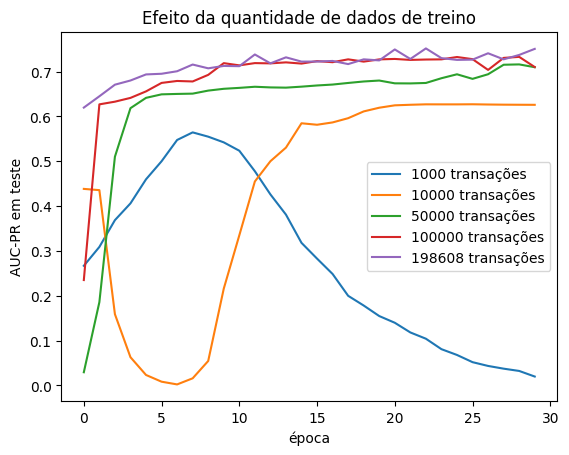

In [ ]:
for n in [1000, 10000, 50000, 100000, len(X_train_scaled)]:
    _, h = treinar_tf(n_treino=n, n_oculta=64, taxa=0.001, epocas=30, class_weight={0: 1.0, 1: 5.0})
    plt.plot(h["auc_pr_teste"], label=f"{n} transações")
    print(f"{n:>7} transações | AUC-PR treino={h['auc_pr_treino'][-1]:.4f} | AUC-PR teste={h['auc_pr_teste'][-1]:.4f}")

plt.xlabel("época"); plt.ylabel("AUC-PR em teste")
plt.legend(); plt.title("Efeito da quantidade de dados de treino")
plt.show()

Com **1.000 transações** a rede não aprende nada (AUC-PR de 0,0196): nesse recorte, quase não
há fraudes para aprender. A AUC-PR em teste sobe com os dados (0,6259, 0,7098, 0,7102 e
0,7507), e com todo o treino chega ao melhor valor.

### Experimento 6: Dropout

Cinco taxas de dropout, com 40 épocas:

In [ ]:
for p in [0.0, 0.1, 0.2, 0.4, 0.6]:
    _, h = treinar_tf(n_oculta=64, taxa=0.001, epocas=40, p_dropout=p, class_weight={0: 1.0, 1: 5.0})
    print(f"dropout={p:.1f} | AUC-PR teste={h['auc_pr_teste'][-1]:.4f} | Perda teste={h['perda_teste'][-1]:.4f}")

dropout=0.0 | AUC-PR teste=0.7843 | Perda teste=0.0064
dropout=0.1 | AUC-PR teste=0.7970 | Perda teste=0.0049
dropout=0.2 | AUC-PR teste=0.7577 | Perda teste=0.0050
dropout=0.4 | AUC-PR teste=0.7226 | Perda teste=0.0047
dropout=0.6 | AUC-PR teste=0.7179 | Perda teste=0.0047


O melhor foi **dropout de 0,1** (AUC-PR 0,7970). Sem dropout fica em 0,7843; de 0,2 em
diante a AUC-PR cai (0,7577, 0,7226 e 0,7179). A rede já é pequena: dropout demais tira
capacidade que ela precisa.

### Experimento 7: Paridade de Pesos (Class Weights Trade-offs)

Cinco pesos para a classe fraude, de 1:1 a 1:100. Para cada um, a rede é treinada por 20
épocas, avaliada no teste com limiar 0,5, e as métricas vão para a tabela e para o gráfico.

Iniciando testes de paridade de pesos. Isso pode levar alguns minutos...

PESO (0:1)   | ACURÁCIA (Geral)   | RECALL (Achou Fraude?)    | PRECISION (Acertou o chute?) | F1-SCORE (Equilíbrio)  | PR-AUC (Global) | ROC-AUC (Distinção) 
-----------------------------------------------------------------------------------------------------------------------------------------------------------
1.0:1.0      | 0.9994             | 0.7746                    | 0.8333                       | 0.8029                 | 0.7759          | 0.9648              
1.0:5.0      | 0.9992             | 0.7887                    | 0.7568                       | 0.7724                 | 0.7497          | 0.9658              
1.0:15.0     | 0.9992             | 0.8028                    | 0.7403                       | 0.7703                 | 0.7398          | 0.9651              
1.0:50.0     | 0.9986             | 0.8451                    | 0.5556                       | 0.6704                 | 0.7388        

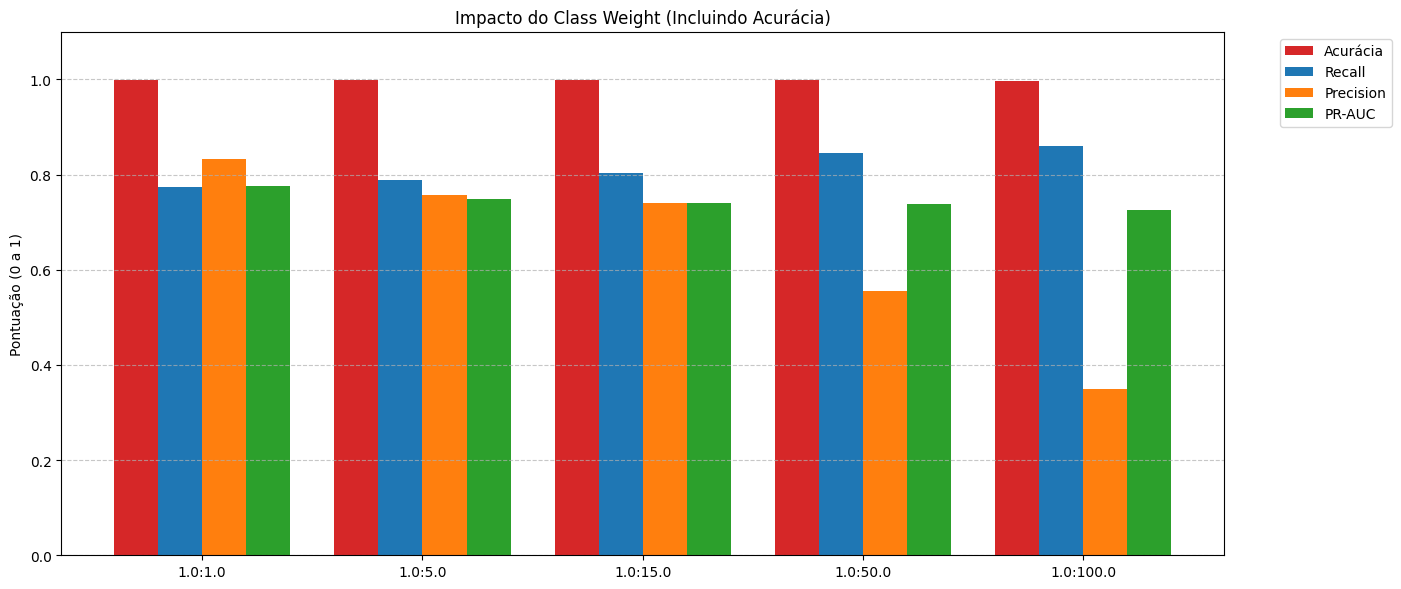

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, average_precision_score, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt

# ====================================================================
# EXPERIMENTO 7: Paridade de Pesos Completa (Com Acurácia e Explicações)
# ====================================================================

cenarios_pesos = [
    {0: 1.0, 1: 1.0},    # Ignora desbalanceamento
    {0: 1.0, 1: 5.0},    # Penalidade leve
    {0: 1.0, 1: 15.0},   # Penalidade moderada
    {0: 1.0, 1: 50.0},   # Penalidade agressiva
    {0: 1.0, 1: 100.0}   # Penalidade extrema
]

resultados = []

print("Iniciando testes de paridade de pesos. Isso pode levar alguns minutos...\n")

# Cabeçalho com TODAS as explicações e espaçamentos ajustados
print(f"{'PESO (0:1)':<12} | {'ACURÁCIA (Geral)':<18} | {'RECALL (Achou Fraude?)':<25} | {'PRECISION (Acertou o chute?)':<28} | {'F1-SCORE (Equilíbrio)':<22} | {'PR-AUC (Global)':<15} | {'ROC-AUC (Distinção)':<20}")
print("-" * 155)

for pesos in cenarios_pesos:
    modelo, _ = treinar_tf(epocas=20, n_oculta=64, class_weight=pesos, verbose=0)

    y_pred_probs = modelo.predict(X_test_scaled, verbose=0).ravel()
    y_pred = (y_pred_probs > 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred, zero_division=0)
    prec = precision_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    pr_auc = average_precision_score(y_test, y_pred_probs)
    roc_auc = roc_auc_score(y_test, y_pred_probs)

    label = f"{pesos[0]}:{pesos[1]}"
    resultados.append((label, acc, rec, prec, f1, pr_auc, roc_auc))

    # Impressão com os novos espaçamentos perfeitamente alinhados
    print(f"{label:<12} | {acc:<18.4f} | {rec:<25.4f} | {prec:<28.4f} | {f1:<22.4f} | {pr_auc:<15.4f} | {roc_auc:<20.4f}")

# ====================================================================
# PLOTANDO O TRADE-OFF COM ACURÁCIA
# ====================================================================
labels = [r[0] for r in resultados]
accs = [r[1] for r in resultados]       # Acurácia
recalls = [r[2] for r in resultados]    # Recall
precisions = [r[3] for r in resultados] # Precision
pr_aucs = [r[5] for r in resultados]    # PR-AUC

x = np.arange(len(labels))
width = 0.2  # Diminuído para caber 4 barras

fig, ax = plt.subplots(figsize=(14, 6))

# Adicionando as 4 barras com espaçamentos ajustados
rects1 = ax.bar(x - 1.5 * width, accs, width, label='Acurácia', color='#d62728')
rects2 = ax.bar(x - 0.5 * width, recalls, width, label='Recall', color='#1f77b4')
rects3 = ax.bar(x + 0.5 * width, precisions, width, label='Precision', color='#ff7f0e')
rects4 = ax.bar(x + 1.5 * width, pr_aucs, width, label='PR-AUC', color='#2ca02c')

ax.set_ylabel('Pontuação (0 a 1)')
ax.set_title('Impacto do Class Weight (Incluindo Acurácia)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
ax.grid(axis='y', linestyle='--', alpha=0.7)

ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

#### Análise do Experimento 7: O Trade-off dos Pesos de Classe e a Ilusão das Métricas Globais

O uso do parâmetro `class_weight` tem um impacto direto no comportamento do modelo ao forçar a rede neural a prestar mais atenção aos erros cometidos na classe minoritária (Fraudes - Classe 1). A tabela de resultados revela três fenômenos fundamentais:

**1. A Ilusão da Acurácia e da ROC-AUC**
Observe como a **Acurácia** mal se move (cai de 99,94% para 99,72%) e a **ROC-AUC** permanece estática na casa dos 0.96, independentemente de quão extrema seja a penalidade. Como as transações normais representam a esmagadora maioria do dataset, o modelo continua acertando quase tudo em volume absoluto. Essas métricas mascaram completamente a drástica mudança de comportamento do modelo em relação às fraudes.

**2. O Trade-off Físico: Recall vs. Precision**
Ao aumentarmos progressivamente o peso da classe 1, observamos uma gangorra matemática clássica operando no limiar padrão de 0.5:
* **Recall (Sensibilidade):** É a capacidade de **encontrar todas as fraudes**. Quando aumentamos o peso da fraude de `1:1` para o extremo de `1:100`, o modelo fica hiper-reativo. O *Recall* salta de **77,4% para 87,3%**. Pouquíssimas fraudes reais passam despercebidas (menos Falsos Negativos).
* **Precision (Valor Preditivo Positivo):** É a confiabilidade do alerta. Ao forçar o modelo a achar fraudes a qualquer custo, ele começa a "chutar" demais. A *Precision* despenca brutalmente de excelentes **83,3% para apenas 35,6%**. Ou seja, no cenário 1:100, de cada 100 cartões bloqueados, cerca de 64 eram de clientes legítimos (explosão de Falsos Positivos).

**3. O Veredito da PR-AUC**
A métrica **PR-AUC** cai levemente (de 0.77 para 0.71), provando que aumentar o peso da classe **não torna o modelo fundamentalmente mais inteligente** em separar fraudes de transações normais; ele apenas força a rede a deslocar sua distribuição de probabilidades, tornando-a mais propensa a disparar o alarme.

---

### Impacto no Negócio (Business Case)

Não existe uma resposta "certa", apenas a escolha do mal menor dependendo da estratégia da empresa:

* **Pesos Baixos (1:1 ou 1:5):** O modelo é conservador. Ele erra ao deixar algumas fraudes passarem (*Recall* ~78%), mas quando bloqueia um cartão, tem alta confiabilidade (*Precision* entre 75% e 83%). Excelente para bancos focados em **experiência do usuário** (evita o bloqueio do cartão do cliente no meio de um jantar).
* **Pesos Altos (1:50 ou 1:100):** O modelo é paranoico. Ele estanca as perdas financeiras interceptando quase 90% das fraudes, mas o custo operacional explode. Muitos clientes legítimos terão seus cartões bloqueados por engano (*Precision* abaixo de 55%), gerando ligações furiosas para o *Call Center* e potencial cancelamento de contas.

A métrica **F1-Score** tenta encontrar o equilíbrio matemático. Nos dados, o F1 máximo ocorreu sem pesos extras (0.80), mas cenários até `1:15` mantêm um F1 sólido (~0.77), representando o limite do balanço aceitável antes de destruir a experiência do usuário.

---

### O Paralelo com Testes de Hipóteses

Essa dinâmica é perfeitamente análoga aos Testes de Hipóteses na estatística clássica, onde precisamos regular o Nível de Significância (alfa) para balancear dois tipos de erros. Se considerarmos a Hipótese Nula (H0) como *"a transação é legítima"*:

1. **Erro do Tipo I (Falso Positivo):** Rejeitar H0 quando ela é verdadeira (bloquear uma compra legítima, prejudicando a *Precision*).
2. **Erro do Tipo II (Falso Negativo):** Não rejeitar H0 quando ela é falsa (deixar uma fraude passar, prejudicando o *Recall*).

Aumentar o peso da classe de fraudes para `1:100` é estatisticamente o mesmo que **aumentar o valor de alfa** (relaxar o rigor da prova). O modelo fica mais disposto a rejeitar a hipótese de que a compra é legítima com muito menos "evidências". Isso minimiza drasticamente o Erro do Tipo II (eleva o Recall), mas inevitavelmente infla o Erro do Tipo I (derruba a Precision).

Como a **PR-AUC** nos mostrou, não é possível reduzir ambos os erros simultaneamente apenas movendo essa régua de decisão (os pesos). Para melhorar as duas pontas ao mesmo tempo, a única saída é aumentar a **capacidade de discriminação** real do teste — coletando mais dados, criando novas *features* ou testando arquiteturas mais avançadas.

---
## Parte 10: Avaliação final no teste

Até aqui, todas as escolhas (modelo e limiar) foram feitas na validação. Agora os três modelos
são aplicados ao teste, cada um com o limiar de menor custo.

Para cada modelo, as probabilidades no teste, o limiar, o relatório de
classificação e a matriz de confusão.

In [ ]:
modelos_finais = {
    "MLP 1": (modelo_mlp1.predict(X_test_scaled).ravel(), melhor_custo_mlp1["Threshold"]),
    "MLP 2": (modelo_mlp2.predict(X_test_scaled).ravel(), melhor_custo_mlp2["Threshold"]),
    "HGB": (modelo_hgb.predict_proba(X_test_scaled)[:, 1], melhor_custo_hgb["Threshold"])
}

for nome, (y_score_test, threshold) in modelos_finais.items():

    y_pred_test = (y_score_test >= threshold).astype(int)

    print(f"\n{nome} | Threshold = {threshold:.2f}")
    print(f"PR-AUC teste: {average_precision_score(y_test, y_score_test):.4f}")
    print(classification_report(y_test, y_pred_test, digits=4, zero_division=0))
    print(confusion_matrix(y_test, y_pred_test))

1330/1330 ━━━━━━━━━━━━━━━━━━━━ 1s 733us/step
1330/1330 ━━━━━━━━━━━━━━━━━━━━ 1s 711us/step

MLP 1 | Threshold = 0.15
PR-AUC teste: 0.7896
              precision    recall  f1-score   support

         0.0     0.9996    0.9995    0.9996     42488
         1.0     0.7368    0.7887    0.7619        71

    accuracy                         0.9992     42559
   macro avg     0.8682    0.8941    0.8807     42559
weighted avg     0.9992    0.9992    0.9992     42559

[[42468    20]
 [   15    56]]

MLP 2 | Threshold = 0.55
PR-AUC teste: 0.7789
              precision    recall  f1-score   support

         0.0     0.9996    0.9996    0.9996     42488
         1.0     0.7671    0.7887    0.7778        71

    accuracy                         0.9992     42559
   macro avg     0.8834    0.8942    0.8887     42559
weighted avg     0.9993    0.9992    0.9993     42559

[[42471    17]
 [   15    56]]

HGB | Threshold = 0.85
PR-AUC teste: 0.5309
              precision    recall  f1-score   support



No teste, **MLP 1 e MLP 2 acham as mesmas 56 de 71 fraudes** (recall de 78,87%); a MLP 2 erra
um pouco menos nas legítimas (17 falsos positivos contra 20). O HGB acha 49 e dá 39 alarmes
falsos. A PR-AUC em teste (0,7896, 0,7789 e 0,5309) repete a ordem da validação.

Uma função que mede o tempo de previsão de cada modelo, a AUPRC, e o limiar de menor custo.

> **Atenção: o resultado desta célula está errado.** Ela recebe `X_val`, **sem a escala** de
> `Time` e `Amount`. As MLPs recebem números numa escala que nunca viram e não acham nenhuma
> fraude (AUPRC 0,0008, recall 0, custo 7.100, igual ao de não checar nada).

In [ ]:
import time
import pandas as pd
from sklearn.metrics import precision_recall_curve, auc

CUSTO_FN = 100  # fraude liberada
CUSTO_FP = 5    # compra legítima bloqueada

# 1. Função para capturar o tempo de inferência
def avaliar_modelo_tempo_e_metricas(nome_modelo, modelo, X_val, y_val, thresholds_teste):
    # Captura do tempo de inferência
    start_time = time.time()
    # Verifica se é uma rede neural do Keras/PyTorch ou modelo Scikit-Learn
    if hasattr(modelo, "predict_proba"):
        y_score = modelo.predict_proba(X_val)[:, 1]
    else:
        y_score = modelo.predict(X_val).ravel() # Para MLP do Keras/TensorFlow
    end_time = time.time()

    tempo_ms = (end_time - start_time) * 1000

    # 2. Cálculo do AUPRC
    precision, recall, _ = precision_recall_curve(y_val, y_score)
    auprc = auc(recall, precision)

    # 3. Avaliação dos Thresholds e Custos usando a sua lógica
    # Certifique-se de que a sua função original "avaliar_thresholds" retorna uma lista de dicionários ou um DataFrame
    resultados_df = pd.DataFrame(avaliar_thresholds(y_val, y_score, thresholds_teste))

    # Aplicando a fórmula de custo
    resultados_df["Custo"] = (CUSTO_FN * resultados_df["FN"]) + (CUSTO_FP * resultados_df["FP"])

    # Pegando o cenário ótimo (menor custo)
    melhor_cenario = resultados_df.loc[resultados_df["Custo"].idxmin()]

    return {
        "Modelo": nome_modelo,
        "Tempo de Inferência (ms)": tempo_ms,
        "AUPRC": auprc,
        "Melhor Threshold": melhor_cenario["Threshold"],
        "Menor Custo": melhor_cenario["Custo"],
        "Recall (no melhor limiar)": melhor_cenario["Recall"] if "Recall" in melhor_cenario else (melhor_cenario["TP"] / (melhor_cenario["TP"] + melhor_cenario["FN"])),
        "Precision (no melhor limiar)": melhor_cenario["Precision"] if "Precision" in melhor_cenario else (melhor_cenario["TP"] / (melhor_cenario["TP"] + melhor_cenario["FP"]))
    }

# --- Aplicação no seu notebook ---
# Substitua 'modelo_mlp1', 'modelo_mlp2' e 'modelo_hgb' pelas variáveis originais dos seus modelos

resultados_finais = []

# MLP 1 (Sem Class Weights)
resultados_finais.append(
    avaliar_modelo_tempo_e_metricas("MLP 1 (Padrão)", modelo_mlp1, X_val, y_val, thresholds_teste)
)

# MLP 2 (Com Class Weights)
resultados_finais.append(
    avaliar_modelo_tempo_e_metricas("MLP 2 (Class Weights)", modelo_mlp2, X_val, y_val, thresholds_teste)
)

# HistGradientBoosting
resultados_finais.append(
    avaliar_modelo_tempo_e_metricas("HistGradientBoosting", modelo_hgb, X_val, y_val, thresholds_teste)
)

# Consolidando em uma tabela final para análise
df_tradeoff = pd.DataFrame(resultados_finais)
display(df_tradeoff)

1330/1330 ━━━━━━━━━━━━━━━━━━━━ 1s 716us/step
1330/1330 ━━━━━━━━━━━━━━━━━━━━ 1s 708us/step


,Modelo,Tempo de Inferência (ms),AUPRC,Melhor Threshold,Menor Custo,Recall (no melhor limiar),Precision (no melhor limiar)
0,MLP 1 (Padrão),1365.287304,0.000834,0.1,7100.0,0.000000,0.000000
1,MLP 2 (Class Weights),1346.301556,0.000834,0.1,7100.0,0.000000,0.000000
2,HistGradientBoosting,30.441761,0.606407,0.7,3040.0,0.676056,0.244898


Limiares mais finos, de 0,01 em 0,01, e o modelo de menor custo na validação é o escolhido.

In [ ]:
thresholds_finos = np.arange(0.01, 1.00, 0.01)

candidatos = {
    "MLP 1": (y_score_mlp1, modelo_mlp1),
    "MLP 2": (y_score_mlp2, modelo_mlp2),
    "HGB": (y_score_hgb, modelo_hgb),
}

melhores = {}

for nome, (score, _) in candidatos.items():
    resultados = avaliar_thresholds(y_val, score, thresholds_finos)
    resultados["Custo"] = CUSTO_FN * resultados["FN"] + CUSTO_FP * resultados["FP"]
    melhores[nome] = resultados.loc[resultados["Custo"].idxmin()]

tabela_custo = pd.DataFrame(melhores).T.sort_values("Custo")
display(tabela_custo)

modelo_escolhido = tabela_custo.index[0]
limiar_escolhido = tabela_custo.iloc[0]["Threshold"]

print(f"Modelo escolhido: {modelo_escolhido} | Limiar: {limiar_escolhido:.2f}")

,Threshold,Precision,Recall,F1,TP,FP,FN,TN,Custo
MLP 2,0.57,0.840580,0.816901,0.828571,58.0,11.0,13.0,42477.0,1355.0
MLP 1,0.03,0.535714,0.845070,0.655738,60.0,52.0,11.0,42436.0,1360.0
HGB,0.85,0.538462,0.690141,0.604938,49.0,42.0,22.0,42446.0,2410.0


Modelo escolhido: MLP 2 | Limiar: 0.57


A **MLP 2 com limiar 0,57** tem o menor custo (1.355), por uma diferença pequena para a MLP 1
(1.360), que precisa de um limiar bem baixo (0,03) para chegar lá. O modelo escolhido é aplicado uma única vez ao teste, e o resultado é traduzido para a
linguagem do cliente.

In [ ]:
if modelo_escolhido == "HGB":
    y_score_final = modelo_hgb.predict_proba(X_test_scaled)[:, 1]
else:
    y_score_final = candidatos[modelo_escolhido][1].predict(X_test_scaled, verbose=0).ravel()

y_pred_final = (y_score_final >= limiar_escolhido).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()

total_fraudes = tp + fn
total_legitimas = tn + fp
custo_modelo = CUSTO_FN * fn + CUSTO_FP * fp
custo_sem_checagem = CUSTO_FN * total_fraudes

print(f"PR-AUC teste: {average_precision_score(y_test, y_score_final):.4f}\n")
print("RESPOSTA PARA O CLIENTE")
print(f"Em {len(y_test):,} compras que o sistema nunca viu:")
print(f"- Fraudes barradas: {tp} de {total_fraudes} ({tp / total_fraudes:.0%})")
print(f"- Fraudes que passaram: {fn}")
print(f"- Clientes bons barrados: {fp} de {total_legitimas:,} ({fp / total_legitimas * 10000:.1f} a cada 10 mil)")
print(f"- De cada 10 compras barradas, {tp / (tp + fp) * 10:.0f} eram fraude")
print(f"- Prejuízo estimado: {custo_modelo:,} (sem checagem nenhuma: {custo_sem_checagem:,})")

PR-AUC teste: 0.7789

RESPOSTA PARA O CLIENTE
Em 42,559 compras que o sistema nunca viu:
- Fraudes barradas: 56 de 71 (79%)
- Fraudes que passaram: 15
- Clientes bons barrados: 17 de 42,488 (4.0 a cada 10 mil)
- De cada 10 compras barradas, 8 eram fraude
- Prejuízo estimado: R$ 1,585 (sem checagem nenhuma: R$ 7,100)


Em 42.559 compras que o modelo nunca viu, ele **barrou 56 das 71 fraudes (79%)** e bloqueou 17
clientes legítimos, 4 a cada 10 mil. O prejuízo estimado cai de 7100 (sem checagem) para 1585.
Como o sistema decidiria transação por transação: uma nota de risco de 0 a 100 e a decisão
(aprovar ou barrar), para três fraudes e três legítimas do teste.

In [ ]:
def avaliar_transacao(indice):
    x = X_test_scaled.loc[[indice]]

    if modelo_escolhido == "HGB":
        nota = modelo_hgb.predict_proba(x)[0, 1]
    else:
        nota = candidatos[modelo_escolhido][1].predict(x, verbose=0)[0, 0]

    decisao = "BARRAR e pedir confirmação" if nota >= limiar_escolhido else "APROVAR"
    real = "fraude" if y_test.loc[indice] == 1 else "legítima"

    print(
        f"Transação {indice} | valor: {X_test.loc[indice, 'Amount']:.2f} | "
        f"nota de risco: {nota * 100:.0f}/100 | decisão: {decisao} | real: {real}"
    )

for i in y_test[y_test == 1].index[:3]:
    avaliar_transacao(i)

for i in y_test[y_test == 0].index[:3]:
    avaliar_transacao(i)

Transação 248322 | valor: 1096.99 | nota de risco: 0/100 | decisão: APROVAR | real: fraude
Transação 100242 | valor: 549.06 | nota de risco: 0/100 | decisão: APROVAR | real: fraude
Transação 6570 | valor: 1.00 | nota de risco: 83/100 | decisão: BARRAR e pedir confirmação | real: fraude
Transação 133635 | valor: 20.64 | nota de risco: 0/100 | decisão: APROVAR | real: legítima
Transação 114060 | valor: 60.17 | nota de risco: 0/100 | decisão: APROVAR | real: legítima
Transação 279467 | valor: 711.56 | nota de risco: 0/100 | decisão: APROVAR | real: legítima


As três legítimas foram aprovadas corretamente. Das três fraudes, só uma foi barrada (nota
83); as outras duas, de 1.096,99 e 549,06, receberam nota 0 e passaram. São exemplos das 15
fraudes que o modelo não pega.

A mesma função da primeira célula da parte 10, agora com `X_val_scaled`, calculando também a acurácia no limiar de
menor custo, e um baseline que aprova tudo. Os gráficos mostram as métricas de cada modelo e o
contraste entre tempo de inferência e custo.

,Modelo,Tempo (ms),Acurácia,AUPRC,Precision,Recall,Custo R$
0,Baseline (Tudo Normal),0.000000,0.998332,0.000000,0.000000,0.000000,7100.0
1,MLP 1 (Padrão),1300.733805,0.999295,0.826822,0.773333,0.816901,1385.0
2,MLP 2 (Class Weights),1291.128874,0.999413,0.825650,0.828571,0.816901,1360.0
3,HistGradientBoosting,30.319691,0.998496,0.606237,0.538462,0.690141,2410.0


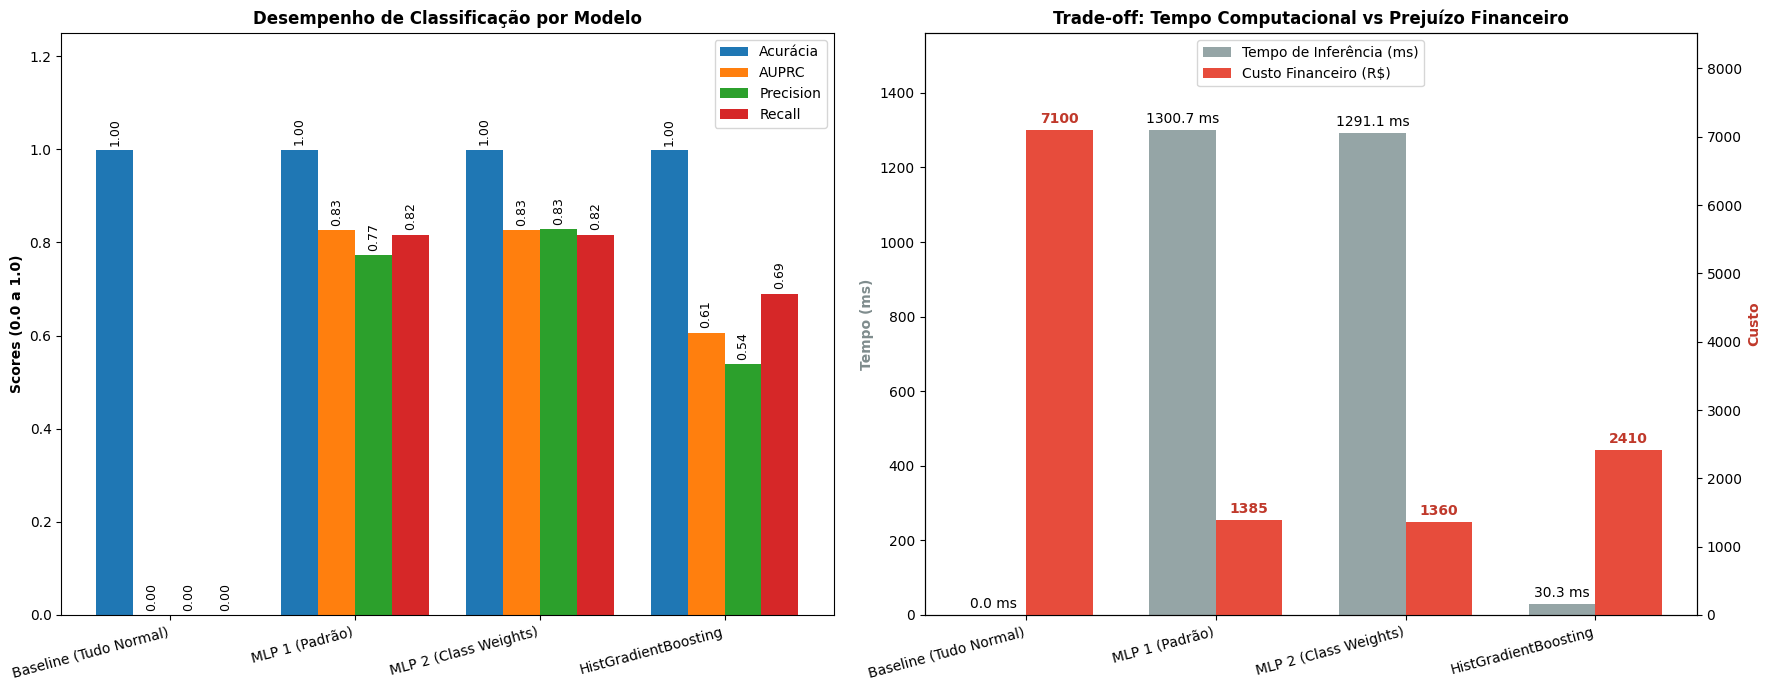

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc, accuracy_score

CUSTO_FN = 100  # fraude liberada
CUSTO_FP = 5    # compra legítima bloqueada

# 1. Função ajustada para extração segura de Keras e Scikit-Learn
def avaliar_modelo_tempo_e_metricas(nome_modelo, modelo, X_val, y_val, thresholds_teste):
    start_time = time.time()

    # Tratamento seguro para modelos Keras vs Scikit-Learn
    if hasattr(modelo, "predict_proba"):
        y_score = modelo.predict_proba(X_val)[:, 1]
    else:
        # O .flatten() garante que (N, 1) vira (N,) evitando bugs no Scikit-Learn
        y_score = modelo.predict(X_val, verbose=0).flatten()

    end_time = time.time()

    tempo_ms = (end_time - start_time) * 1000

    precision, recall, _ = precision_recall_curve(y_val, y_score)
    auprc = auc(recall, precision)

    resultados_df = pd.DataFrame(avaliar_thresholds(y_val, y_score, thresholds_teste))
    resultados_df["Custo"] = (CUSTO_FN * resultados_df["FN"]) + (CUSTO_FP * resultados_df["FP"])

    melhor_cenario = resultados_df.loc[resultados_df["Custo"].idxmin()]
    melhor_threshold = melhor_cenario["Threshold"]

    y_pred_otimo = (y_score >= melhor_threshold).astype(int)
    acuracia = accuracy_score(y_val, y_pred_otimo)

    return {
        "Modelo": nome_modelo,
        "Tempo (ms)": tempo_ms,
        "Acurácia": acuracia,
        "AUPRC": auprc,
        "Precision": melhor_cenario.get("Precision", melhor_cenario["TP"] / max((melhor_cenario["TP"] + melhor_cenario["FP"]), 1)),
        "Recall": melhor_cenario.get("Recall", melhor_cenario["TP"] / max((melhor_cenario["TP"] + melhor_cenario["FN"]), 1)),
        "Custo": melhor_cenario["Custo"]
    }

def avaliar_baseline(y_val):
    fn = sum(y_val == 1)
    fp = 0
    tn = sum(y_val == 0)

    custo = (CUSTO_FN * fn) + (CUSTO_FP * fp)
    acuracia = tn / len(y_val)

    return {
        "Modelo": "Baseline (Tudo Normal)",
        "Tempo (ms)": 0.0,
        "Acurácia": acuracia,
        "AUPRC": 0.0,
        "Precision": 0.0,
        "Recall": 0.0,
        "Custo": custo
    }

# --- Consolidação dos Resultados ---
resultados_finais = []

# Baseline
resultados_finais.append(avaliar_baseline(y_val))

# Modelos Reais
resultados_finais.append(avaliar_modelo_tempo_e_metricas("MLP 1 (Padrão)", modelo_mlp1, X_val_scaled, y_val, thresholds_teste))
resultados_finais.append(avaliar_modelo_tempo_e_metricas("MLP 2 (Class Weights)", modelo_mlp2, X_val_scaled, y_val, thresholds_teste))
resultados_finais.append(avaliar_modelo_tempo_e_metricas("HistGradientBoosting", modelo_hgb, X_val_scaled, y_val, thresholds_teste))

df_tradeoff = pd.DataFrame(resultados_finais)
display(df_tradeoff)

# --- Plotagem do Gráfico de Barras Agrupado com Valores ---
metricas_percentuais = ['Acurácia', 'AUPRC', 'Precision', 'Recall']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

x = np.arange(len(df_tradeoff['Modelo']))
width = 0.2

# Gráfico 1: Métricas de Qualidade Agrupadas
for i, metrica in enumerate(metricas_percentuais):
    deslocamento = (i - 1.5) * width
    bar = ax1.bar(x + deslocamento, df_tradeoff[metrica], width, label=metrica)
    # Adicionando o valor exato no topo das barras
    ax1.bar_label(bar, fmt='%.2f', padding=3, fontsize=9, rotation=90)

ax1.set_ylabel('Scores (0.0 a 1.0)', weight='bold')
ax1.set_title('Desempenho de Classificação por Modelo', weight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(df_tradeoff['Modelo'], rotation=15, ha='right')
ax1.set_ylim(0, 1.25) # Espaço extra no topo para caber os rótulos rotacionados
ax1.legend(loc='upper right')

# Gráfico 2: Custo e Tempo
largura_dupla = 0.35
ax2_custo = ax2.twinx()

bar1 = ax2.bar(x - largura_dupla/2, df_tradeoff['Tempo (ms)'], largura_dupla, color='#95a5a6', label='Tempo de Inferência (ms)')
# Rótulo de tempo
ax2.bar_label(bar1, fmt='%.1f ms', padding=3, fontsize=10)

bar2 = ax2_custo.bar(x + largura_dupla/2, df_tradeoff['Custo'], largura_dupla, color='#e74c3c', label='Custo')
# Rótulo de custo
ax2_custo.bar_label(bar2, fmt='%d', padding=3, fontsize=10, color='#c0392b', weight='bold')

ax2.set_ylabel('Tempo (ms)', weight='bold', color='#7f8c8d')
ax2_custo.set_ylabel('Custo', weight='bold', color='#c0392b')
ax2.set_title('Trade-off: Tempo Computacional vs Prejuízo Financeiro', weight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(df_tradeoff['Modelo'], rotation=15, ha='right')

# Limites extras para não cortar os textos do topo
ax2.set_ylim(0, df_tradeoff['Tempo (ms)'].max() * 1.2)
ax2_custo.set_ylim(0, df_tradeoff['Custo'].max() * 1.2)

bars = [bar1, bar2]
labels = [bar.get_label() for bar in bars]
ax2.legend(bars, labels, loc='upper center')

plt.tight_layout()
plt.show()

O HGB é
cerca de **40 vezes mais rápido** na inferência (30 ms contra 1,3 s para as 42.559 transações),
mas custa quase o dobro (2.410).

### Avaliação usando dados de teste

,Modelo,Tempo (ms),Acurácia,AUPRC,Precision,Recall,Custo R$
0,Baseline (Tudo Normal),0.000000,0.998332,0.000000,0.000000,0.000000,7100.0
1,MLP 1 (Padrão),1299.074173,0.999319,0.788764,0.800000,0.788732,1570.0
2,MLP 2 (Class Weights),1300.161362,0.998966,0.778070,0.651685,0.816901,1455.0
3,HistGradientBoosting,31.368494,0.998449,0.599848,0.526316,0.704225,2325.0


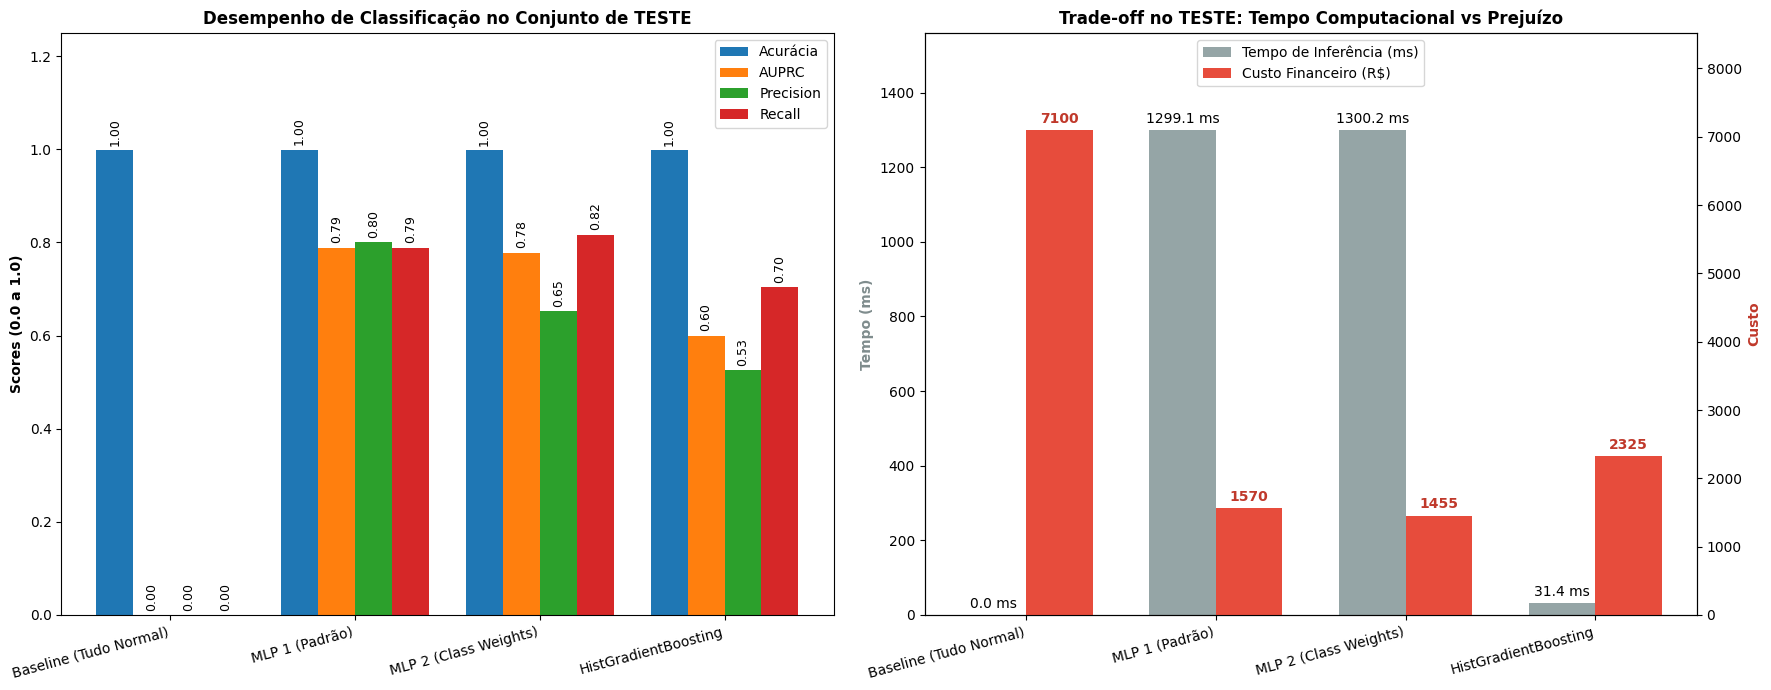

In [ ]:
resultados_teste_finais = []
x
# 1. Baseline no Teste
resultados_teste_finais.append(avaliar_baseline(y_test))

# 2. MLP 1 no Teste
resultados_teste_finais.append(
    avaliar_modelo_tempo_e_metricas(
        "MLP 1 (Padrão)",
        modelo_mlp1,
        X_test_scaled,
        y_test,
        thresholds_teste
    )
)

# 3. MLP 2 (Class Weights) no Teste
resultados_teste_finais.append(
    avaliar_modelo_tempo_e_metricas(
        "MLP 2 (Class Weights)",
        modelo_mlp2,
        X_test_scaled,
        y_test,
        thresholds_teste
    )
)

# 4. HistGradientBoosting no Teste
resultados_teste_finais.append(
    avaliar_modelo_tempo_e_metricas(
        "HistGradientBoosting",
        modelo_hgb,
        X_test_scaled,
        y_test,
        thresholds_teste
    )
)

# Consolidação final no teste
df_tradeoff_teste = pd.DataFrame(resultados_teste_finais)
display(df_tradeoff_teste)

# Re-plotando os gráficos com os resultados REAIS do conjunto de teste
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
x = np.arange(len(df_tradeoff_teste['Modelo']))
width = 0.2

for i, metrica in enumerate(metricas_percentuais):
    deslocamento = (i - 1.5) * width
    bar = ax1.bar(x + deslocamento, df_tradeoff_teste[metrica], width, label=metrica)
    ax1.bar_label(bar, fmt='%.2f', padding=3, fontsize=9, rotation=90)

ax1.set_ylabel('Scores (0.0 a 1.0)', weight='bold')
ax1.set_title('Desempenho de Classificação no Conjunto de TESTE', weight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(df_tradeoff_teste['Modelo'], rotation=15, ha='right')
ax1.set_ylim(0, 1.25)
ax1.legend(loc='upper right')

largura_dupla = 0.35
ax2_custo = ax2.twinx()

bar1 = ax2.bar(x - largura_dupla/2, df_tradeoff_teste['Tempo (ms)'], largura_dupla, color='#95a5a6', label='Tempo de Inferência (ms)')
ax2.bar_label(bar1, fmt='%.1f ms', padding=3, fontsize=10)

bar2 = ax2_custo.bar(x + largura_dupla/2, df_tradeoff_teste['Custo'], largura_dupla, color='#e74c3c', label='Custo')
ax2_custo.bar_label(bar2, fmt='%d', padding=3, fontsize=10, color='#c0392b', weight='bold')

ax2.set_ylabel('Tempo (ms)', weight='bold', color='#7f8c8d')
ax2_custo.set_ylabel('Custo', weight='bold', color='#c0392b')
ax2.set_title('Trade-off no TESTE: Tempo Computacional vs Prejuízo', weight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(df_tradeoff_teste['Modelo'], rotation=15, ha='right')

ax2.set_ylim(0, max(df_tradeoff_teste['Tempo (ms)'].max() * 1.2, 1.0))
ax2_custo.set_ylim(0, df_tradeoff_teste['Custo'].max() * 1.2)

bars = [bar1, bar2]
labels = [bar.get_label() for bar in bars]
ax2.legend(bars, labels, loc='upper center')

plt.tight_layout()
plt.show()

No teste, a MLP 2 tem o menor custo (1.455), seguida da MLP 1 (1.570) e do HGB (2.325). Todos
ficam muito abaixo dos 7.100 de aprovar tudo, e o baseline mostra de novo o problema da
acurácia: 99,83% sem achar fraude nenhuma.